# jiRAG — Jira Retrieval-Augmented Generation Assistant

`jiRAG` is a reproducible RAG system over 1,000 anonymized Jira tickets. The
implemented pipeline validates and versions the data, builds ticket-level RAG
documents, embeds them in a persistent FAISS vector store, retrieves and
reranks evidence, and generates grounded Gemma answers with ticket citations.

This notebook is the explanatory entry point. Reusable implementation lives in
`src/jirag`, versioned inputs and configuration live in Git, and generated
artifacts are persisted separately in Google Drive.


## 0. Environment and Reproducibility

### Goal and principle

This section creates a reproducible execution environment before any data is
processed. **Git is the source of truth** for code, the approved raw dataset,
requirements and configuration. **Google Drive stores generated artifacts**
such as processed data, embeddings, indexes, reports and model checkpoints.

The first run clones the complete repository. Later runs use a fast-forward
pull, so Git downloads only changed files. The executed Git commit, package
versions and random seed are recorded for traceability.

Exact bitwise equality is not guaranteed across every GPU kernel and hardware configuration, even when all random seeds are fixed. The Hugging Face token is not required in Section 0; its secure availability is checked only before gated Gemma generation.


In [1]:
# 0.1 Git-first bootstrap: clone once, then pull only repository changes.
import subprocess
import sys
from pathlib import Path

from google.colab import drive

REPO_URL = "https://github.com/Sagitb/rag_project_google_reichman.git"
PROJECT_REF = "main"

DRIVE_PROJECT_ROOT = Path("/content/drive/MyDrive/jiRAG")
REPO_ROOT = DRIVE_PROJECT_ROOT / "repository"
ARTIFACT_ROOT = DRIVE_PROJECT_ROOT / "artifacts"

drive.mount("/content/drive")
DRIVE_PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

if not (REPO_ROOT / ".git").exists():
    print("[INFO] Repository not found; cloning the complete project once.")
    subprocess.run(
        [
            "git",
            "clone",
            "--branch",
            PROJECT_REF,
            "--single-branch",
            REPO_URL,
            str(REPO_ROOT),
        ],
        check=True,
    )
    GIT_ACTION = "CLONE"
else:
    local_changes = subprocess.run(
        ["git", "-C", str(REPO_ROOT), "status", "--porcelain"],
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
    if local_changes:
        raise RuntimeError(
            "The persistent repository contains local changes. Commit or remove "
            "them before allowing the notebook to pull a different version."
        )

    print("[INFO] Existing repository found; pulling changed files only.")
    subprocess.run(
        [
            "git",
            "-C",
            str(REPO_ROOT),
            "pull",
            "--ff-only",
            "origin",
            PROJECT_REF,
        ],
        check=True,
    )
    GIT_ACTION = "PULL"

REQUIREMENTS_PATH = REPO_ROOT / "requirements.txt"
SOURCE_ROOT = REPO_ROOT / "src"
RAW_DATASET_PATH = (
    REPO_ROOT / "data" / "raw" / "jira_rag_master_FINAL_1000.csv"
)

required_git_files = {
    "requirements": REQUIREMENTS_PATH,
    "source package": SOURCE_ROOT / "jirag" / "__init__.py",
    "raw dataset": RAW_DATASET_PATH,
}
missing_git_files = [
    f"{name}: {path}"
    for name, path in required_git_files.items()
    if not path.is_file()
]
if missing_git_files:
    raise FileNotFoundError(
        "The cloned repository is incomplete:\n- "
        + "\n- ".join(missing_git_files)
    )

if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

print(f"[INFO] Git action: {GIT_ACTION}")
print(f"[INFO] Repository: {REPO_ROOT}")
print(f"[INFO] Raw dataset: {RAW_DATASET_PATH}")


Mounted at /content/drive
[INFO] Existing repository found; pulling changed files only.
[INFO] Git action: PULL
[INFO] Repository: /content/drive/MyDrive/jiRAG/repository
[INFO] Raw dataset: /content/drive/MyDrive/jiRAG/repository/data/raw/jira_rag_master_FINAL_1000.csv


### Dependency contract

Dependencies are versioned in `requirements.txt` and installed only after the
repository is available. Pip keeps already compatible packages; PyTorch is
intentionally not installed because Colab supplies the CUDA-compatible build.


In [2]:
# 0.2 Install the versioned project dependencies without replacing PyTorch.
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--upgrade-strategy",
        "only-if-needed",
        "-r",
        str(REQUIREMENTS_PATH),
    ],
    check=True,
)
print("[INFO] Project dependencies are available.")


[INFO] Project dependencies are available.


### Project configuration and persistent paths

Configuration and reusable utilities are imported from `src/jirag`. Source
paths always point to the Git repository; output paths always point to the
Drive artifact area. This prevents generated files from being mistaken for
versioned project inputs.


In [3]:
# 0.3 Import shared infrastructure and initialize reproducibility.
# Compatibility imports remain here while Sections 1–13 are refactored in order.
import csv
import hashlib
import json
import os
import platform
import random
import re
import shutil
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import sklearn
import torch

from jirag.artifacts import (
    calculate_sha256,
    save_config_snapshot,
    write_run_metadata,
)
from jirag.config import get_base_config, set_global_seed
from jirag.paths import build_project_paths, create_artifact_directories

CONFIG = get_base_config()
CONFIG["project_ref"] = PROJECT_REF

PATHS = build_project_paths(REPO_ROOT, ARTIFACT_ROOT)
create_artifact_directories(PATHS)

# Compatibility alias used by the existing later sections.
PROJECT_ROOT = ARTIFACT_ROOT
RAW_DATASET_PATH = PATHS["data_raw"] / CONFIG["dataset_filename"]

set_global_seed(CONFIG["random_seed"])
SEED_INITIALIZED = True


def save_run_metadata(stage_name, extra_metadata=None):
    """Compatibility wrapper used until later sections move fully into src."""
    output_path = write_run_metadata(
        stage_name=stage_name,
        config=CONFIG,
        logs_dir=PATHS["logs"],
        extra_metadata=extra_metadata,
    )
    print(f"[INFO] Run metadata: {output_path.name}")
    return output_path


CONFIG_SNAPSHOT_PATH = save_config_snapshot(
    CONFIG,
    PATHS["data_manifests"],
)


### Environment evidence and completion gate

The compact environment table records the runtime used for the experiment.
The completion gate then blocks later sections if the repository, dataset,
artifact storage, split configuration or reproducibility seed is invalid.


In [4]:
# 0.4 Inspect and validate the complete bootstrap contract.
GIT_COMMIT = subprocess.run(
    ["git", "-C", str(REPO_ROOT), "rev-parse", "--short", "HEAD"],
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()

environment_summary = pd.DataFrame(
    [
        ("Git action", GIT_ACTION),
        ("Git ref", PROJECT_REF),
        ("Git commit", GIT_COMMIT),
        ("Python", platform.python_version()),
        ("Pandas", pd.__version__),
        ("NumPy", np.__version__),
        ("Scikit-learn", sklearn.__version__),
        ("PyTorch", torch.__version__),
        ("CUDA available", torch.cuda.is_available()),
        (
            "Compute device",
            torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
        ),
        ("Repository root", str(REPO_ROOT)),
        ("Artifact root", str(ARTIFACT_ROOT)),
        ("Dataset", str(RAW_DATASET_PATH)),
    ],
    columns=["Field", "Value"],
)
display(environment_summary)


def validate_bootstrap():
    """Fail early when the Git-first runtime cannot support later sections."""
    errors = []
    required_paths = {
        "Git repository": REPO_ROOT / ".git",
        "source package": PATHS["src"] / "jirag" / "__init__.py",
        "requirements file": REQUIREMENTS_PATH,
        "raw dataset": RAW_DATASET_PATH,
        "config snapshot": CONFIG_SNAPSHOT_PATH,
    }

    for name, path in required_paths.items():
        if not path.exists():
            errors.append(f"Missing {name}: {path}")

    if RAW_DATASET_PATH.exists() and RAW_DATASET_PATH.stat().st_size == 0:
        errors.append(f"Raw dataset is empty: {RAW_DATASET_PATH}")

    split_total = sum(
        CONFIG[key]
        for key in ("train_ratio", "validation_ratio", "test_ratio")
    )
    if abs(split_total - 1.0) > 1e-9:
        errors.append(f"Split ratios sum to {split_total}, not 1.0")

    if not SEED_INITIALIZED:
        errors.append("Global random seed was not initialized")

    try:
        write_probe = ARTIFACT_ROOT / ".write_probe"
        write_probe.write_text("ok", encoding="utf-8")
        write_probe.unlink()
    except OSError as exc:
        errors.append(f"Artifact root is not writable: {exc}")

    if errors:
        raise RuntimeError(
            "Section 0 validation failed:\n- " + "\n- ".join(errors)
        )


validate_bootstrap()
save_run_metadata(
    "project_bootstrap",
    {
        "git_action": GIT_ACTION,
        "git_ref": PROJECT_REF,
        "git_commit": GIT_COMMIT,
        "raw_dataset_sha256": calculate_sha256(RAW_DATASET_PATH),
    },
)

print("✅ Section 0 complete: Git sources, raw data and artifact storage are ready.")


,Field,Value
0,Git action,PULL
1,Git ref,main
2,Git commit,efebf2a
3,Python,3.13.15
4,Pandas,2.2.3
5,NumPy,2.1.3
6,Scikit-learn,1.6.1
7,PyTorch,2.11.0+cu128
8,CUDA available,True
9,Compute device,NVIDIA A100-SXM4-40GB


[INFO] Run metadata: run_project_bootstrap_latest.json
✅ Section 0 complete: Git sources, raw data and artifact storage are ready.


### Section 0 result

Section 0 establishes one reproducible boundary:

- **Git repository:** notebook, source code, requirements, configuration and
  the approved raw dataset.
- **Google Drive artifacts:** processed data, splits, embeddings, vector
  indexes, reports, checkpoints and model adapters.

On a clean Drive, the repository is cloned once. On subsequent runs, only Git
changes are pulled. No dataset processing is performed until Section 1.


## 1. Approved Dataset Loading and Validation

### Goal and principle

This section establishes a trustworthy data boundary before EDA, embeddings or
RAG. It verifies that the Git-tracked Jira CSV is the approved 1,000-ticket
dataset, normalizes the three repeated `Labels` columns in memory, and blocks
the pipeline when schema, identity, workflow, content-structure or privacy
rules fail.

The raw CSV is never modified. A normalized processed copy and its QA evidence
are created under Drive artifacts on the first compatible run and loaded on
later runs.


### Dataset contract

The complete, versioned validation rules live in
`configs/dataset_contract.json`. Keeping the contract outside the notebook
makes the approved schema explicit and reviewable without mixing dozens of
constants into the execution code.

The main gates verify:

- Jira-compatible raw headers and row widths.
- Exact normalized schema, non-empty values and unique sequential ticket IDs.
- Approved category values and designed family/solution balance.
- Consistency between `solution_type` and Jira `Status`.
- Seven ordered, non-empty description sections.
- Absence of email addresses and credential assignments.
- A byte-level raw SHA-256 and a line-ending-independent canonical SHA-256.

Description length remains a secondary contract check from dataset creation;
it is not treated as a headline analytical metric.


In [5]:
# 1.1 Validate the raw source and BUILD or LOAD the processed dataset.
from jirag.data_pipeline import ensure_validated_dataset, load_dataset_contract

DATASET_CONTRACT_PATH = PATHS["configs"] / "dataset_contract.json"
PROCESSED_DATASET_PATH = PATHS["data_processed"] / "tickets_clean_v1.csv"
DATASET_MANIFEST_PATH = (
    PATHS["data_manifests"] / "dataset_manifest_final_1000_v1.json"
)
DATA_QA_REPORT_PATH = (
    PATHS["reports_qa"] / "dataset_qa_final_1000_v1.json"
)

dataset_artifact_paths = {
    "processed": PROCESSED_DATASET_PATH,
    "manifest": DATASET_MANIFEST_PATH,
    "qa_report": DATA_QA_REPORT_PATH,
}

dataset_contract = load_dataset_contract(DATASET_CONTRACT_PATH)
dataset_result = ensure_validated_dataset(
    raw_path=RAW_DATASET_PATH,
    contract_path=DATASET_CONTRACT_PATH,
    artifact_paths=dataset_artifact_paths,
)

# Public objects retained for the next notebook sections.
tickets_df = dataset_result["tickets_df"]
raw_sha256 = dataset_result["raw_sha256"]
canonical_sha256 = dataset_result["canonical_sha256"]
validation_errors = dataset_result["errors"]
validation_warnings = dataset_result["warnings"]
qa_report = dataset_result["qa_report"]
manifest = dataset_result["manifest"]

# Temporary compatibility names used by the existing Section 2 implementation.
EXPECTED_NORMALIZED_COLUMNS = dataset_contract["normalized_columns"]
REQUIRED_DESC_HEADINGS = dataset_contract["description_headings"]


### Validation evidence

The compact table reports only the facts needed to approve the data layer.
Detailed row-level rules and any failures are persisted in the QA artifact
rather than expanded inside the notebook.


In [6]:
# 1.2 Display concise dataset-quality evidence.
dataset_summary = pd.DataFrame(
    [
        ("Artifact action", dataset_result["action"]),
        ("Raw rows", dataset_result["raw_row_count"]),
        ("Raw columns", len(dataset_result["raw_header"])),
        ("Normalized rows", len(tickets_df)),
        ("Normalized columns", len(tickets_df.columns)),
        ("Unique ticket IDs", tickets_df["ticket_id"].nunique()),
        ("Validation errors", len(validation_errors)),
        ("Validation warnings", len(validation_warnings)),
        ("Raw SHA-256", raw_sha256),
        ("Canonical SHA-256", canonical_sha256),
    ],
    columns=["Check", "Result"],
)
display(dataset_summary)

preview_columns = [
    "ticket_id",
    "Summary",
    "Work Type",
    "Priority",
    "Status",
    "Component",
    "family",
    "solution_type",
]
display(tickets_df.loc[:, preview_columns].head(3))


,Check,Result
0,Artifact action,LOAD
1,Raw rows,1000
2,Raw columns,9
3,Normalized rows,1000
4,Normalized columns,9
5,Unique ticket IDs,1000
6,Validation errors,0
7,Validation warnings,0
8,Raw SHA-256,31980a9de00341760859c11cc590a84644a150d47fb2de...
9,Canonical SHA-256,eab7eb446a05d750fb86b9b6d74646bdb43fec88e1e76c...


,ticket_id,Summary,Work Type,Priority,Status,Component,family,solution_type
0,tckt-0001,Latest email engagement is not classified corr...,Story,Medium,Done,Salesforce Email Automation,family-email-activity,solution-verified
1,tckt-0002,Hebrew natural-language questions generate inc...,Task,Medium,In Progress,Natural Language to SOQL,family-ai-to-soql,solution-partial
2,tckt-0003,Credits and contract conversions need a tracea...,Task,Medium,In Progress,Opportunity Credits and Conversions,family-revenue-operations,solution-partial


### Persistence and reload gate

Passing in-memory checks is not enough: downstream sections consume the
persisted processed dataset. The final gate therefore reloads that CSV,
compares it with the validated DataFrame, verifies the manifest fingerprint,
and confirms that all generated files are stored under Drive artifacts rather
than inside the Git repository.


In [7]:
# 1.3 Verify persisted artifacts and record the completed data stage.
reloaded_tickets_df = pd.read_csv(PROCESSED_DATASET_PATH, encoding="utf-8")
pd.testing.assert_frame_equal(
    reloaded_tickets_df,
    tickets_df,
    check_dtype=False,
)

if manifest["processed_sha256"] != calculate_sha256(PROCESSED_DATASET_PATH):
    raise RuntimeError("Processed dataset fingerprint does not match its manifest")

for artifact_path in dataset_artifact_paths.values():
    if not artifact_path.is_relative_to(ARTIFACT_ROOT):
        raise RuntimeError(f"Generated artifact escaped Drive storage: {artifact_path}")

artifact_summary = pd.DataFrame(
    [
        ("Processed dataset", PROCESSED_DATASET_PATH),
        ("Dataset manifest", DATASET_MANIFEST_PATH),
        ("QA report", DATA_QA_REPORT_PATH),
    ],
    columns=["Artifact", "Drive path"],
)
display(artifact_summary)

save_run_metadata(
    "final_dataset_validation",
    {
        "action": dataset_result["action"],
        "rows": len(tickets_df),
        "raw_sha256": raw_sha256,
        "canonical_sha256": canonical_sha256,
        "validation_result": "passed",
    },
)

action_label = "built" if dataset_result["action"] == "BUILD" else "loaded"
print(
    "✅ Section 1 complete: approved dataset validated; "
    f"artifacts {action_label} successfully."
)


,Artifact,Drive path
0,Processed dataset,/content/drive/MyDrive/jiRAG/artifacts/data/pr...
1,Dataset manifest,/content/drive/MyDrive/jiRAG/artifacts/data/ma...
2,QA report,/content/drive/MyDrive/jiRAG/artifacts/reports...


[INFO] Run metadata: run_final_dataset_validation_latest.json
✅ Section 1 complete: approved dataset validated; artifacts loaded successfully.


### Section 1 result

- The approved raw dataset was loaded from the Git repository and remained
  unchanged.
- Jira's repeated `Labels` headers were normalized only in the working and
  processed representations.
- Schema, identity, category balance, workflow, description structure and
  privacy gates passed with zero errors and zero warnings.
- The processed dataset, manifest and QA report were persisted under Drive
  artifacts and passed a reload/fingerprint check.

The validated `tickets_df` is now the sole tabular input to the EDA stage.


## 2. Focused Exploratory Data Analysis

### Goal and principle

This section examines the validated `tickets_df` produced by Section 1. It
does not reload the raw CSV or repeat data-quality checks. The analysis is
limited to evidence that affects managerial questions, retrieval coverage and
the interpretation of generated answers.

Figures are built once and stored under Drive artifacts. A compatible later
run loads the saved summary and figures, while still displaying them in the
main notebook.


In [8]:
# 2.1 BUILD or LOAD the versioned EDA summary and figures.
from IPython.display import Image, Markdown

from jirag.eda import EDA_VERSION, ensure_eda_artifacts

ORIGINAL_TICKETS_SCHEMA = tuple(tickets_df.columns)
EDA_SUMMARY_PATH = PATHS["reports_qa"] / "eda_summary_v2.json"
eda_artifact_paths = {
    "operational": PATHS["reports_figs"] / "eda_operational_overview_v2.png",
    "family_solution": PATHS["reports_figs"] / "eda_family_solution_v2.png",
    "status_solution": PATHS["reports_figs"] / "eda_status_solution_v2.png",
    "summary": EDA_SUMMARY_PATH,
}

eda_result = ensure_eda_artifacts(
    tickets_df=tickets_df,
    canonical_sha256=canonical_sha256,
    artifact_paths=eda_artifact_paths,
)
eda_summary = eda_result["summary"]
print(f"[INFO] EDA artifact action: {eda_result['action']}")


[INFO] EDA artifact action: LOAD


### Operational profile and retrieval coverage

The overview reports only the scale and cardinalities needed for later design
decisions. The figures then show operational fields used in management
questions, solution coverage across technical families, and the relationship
between Jira workflow status and actual solution quality.


,Measure,Value
0,Tickets,1000
1,Technical families,10
2,Solution types,4
3,Unique components,998
4,Open tickets,359
5,Done tickets,641


#### Operational dataset profile

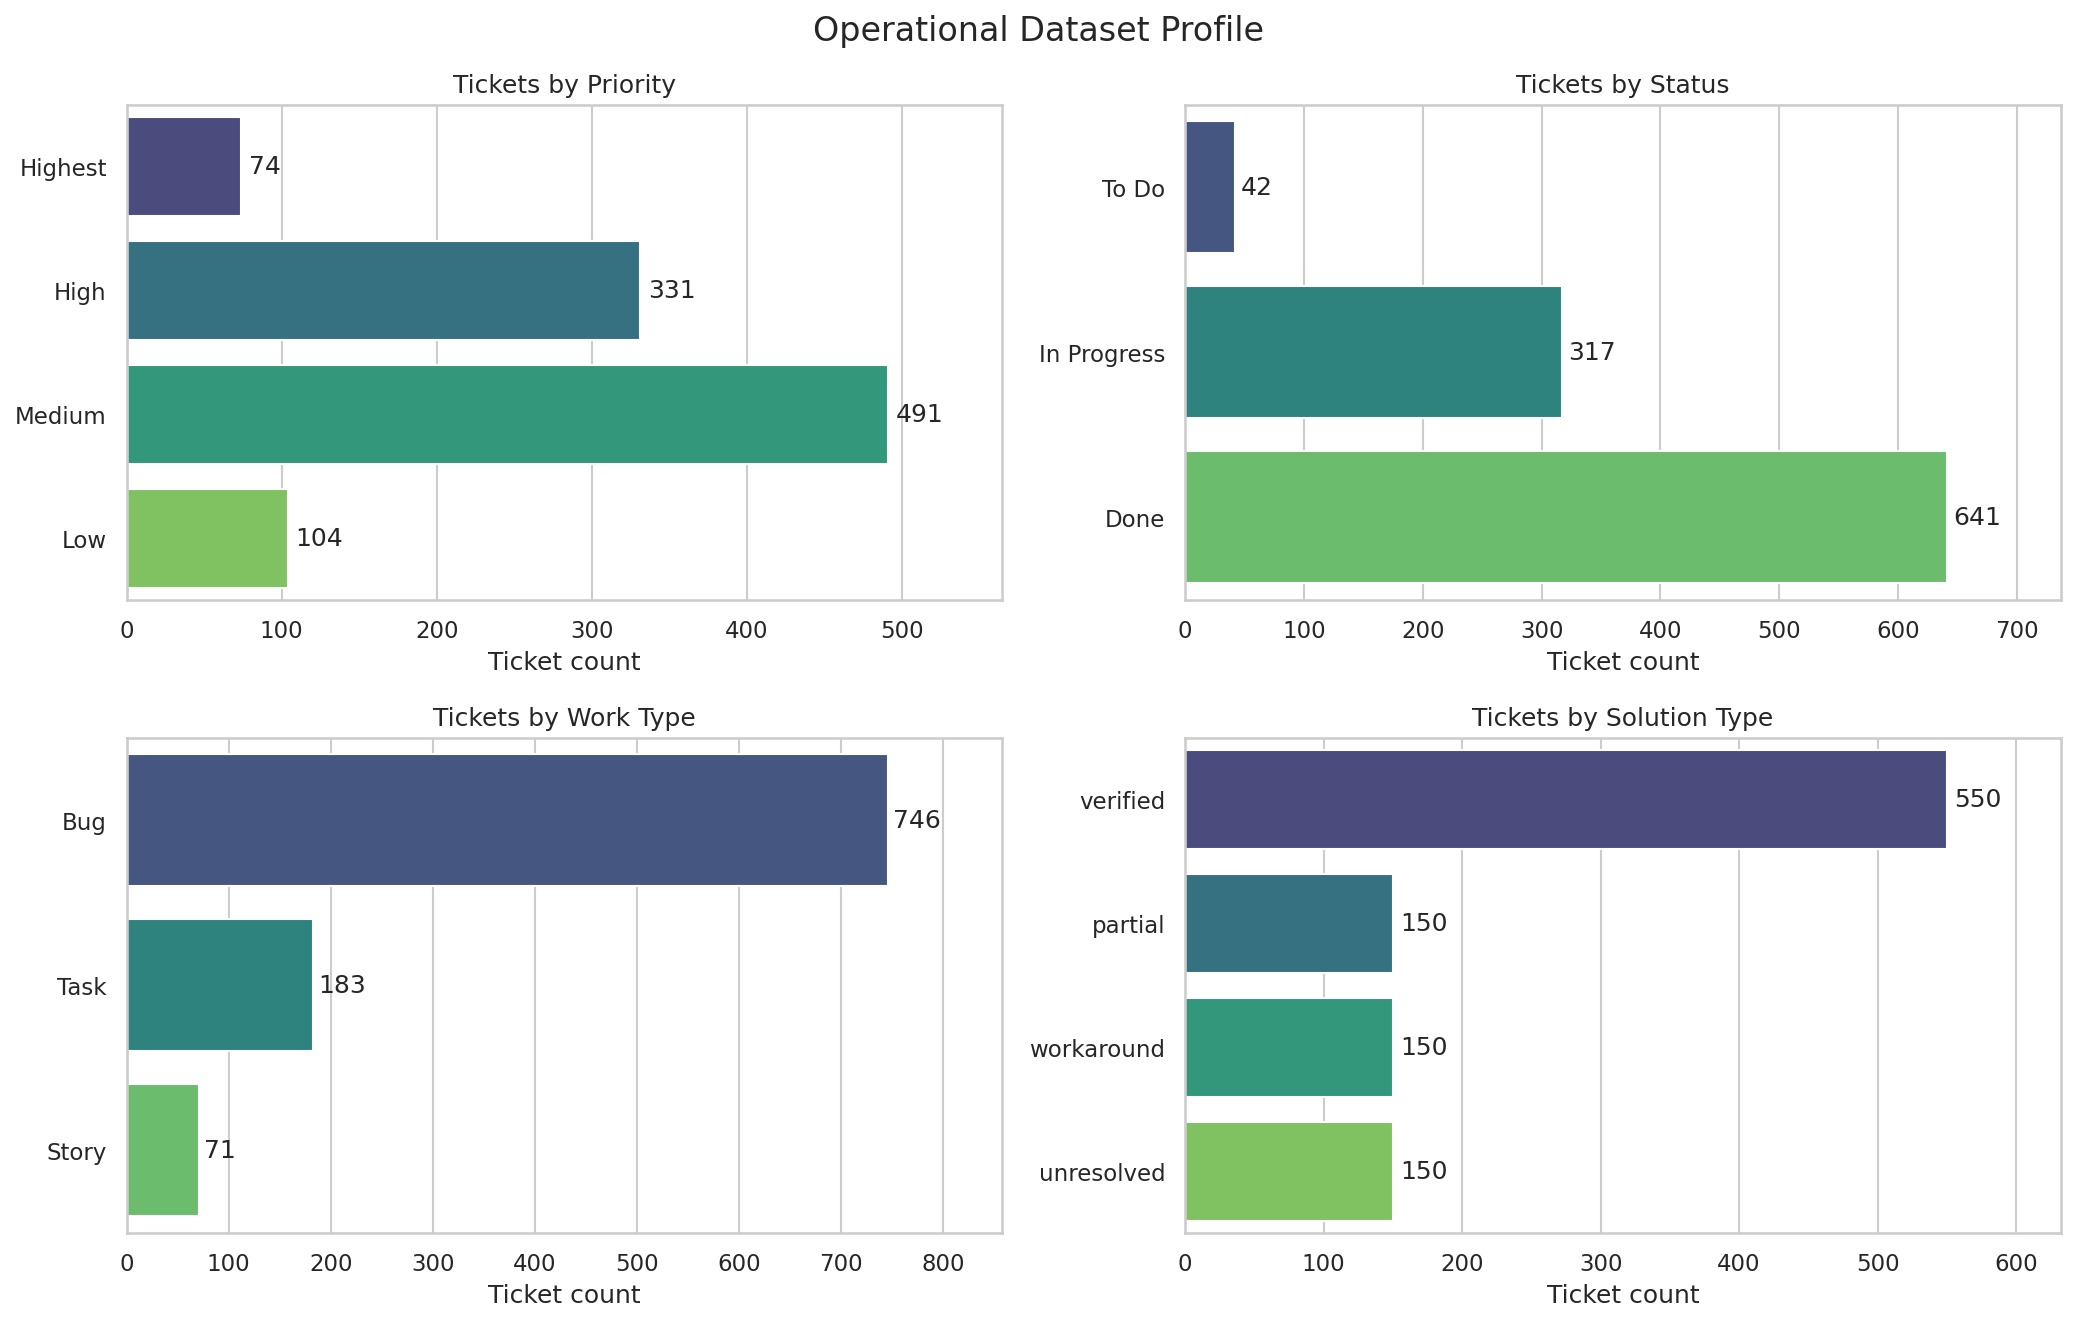

#### Solution coverage within each family

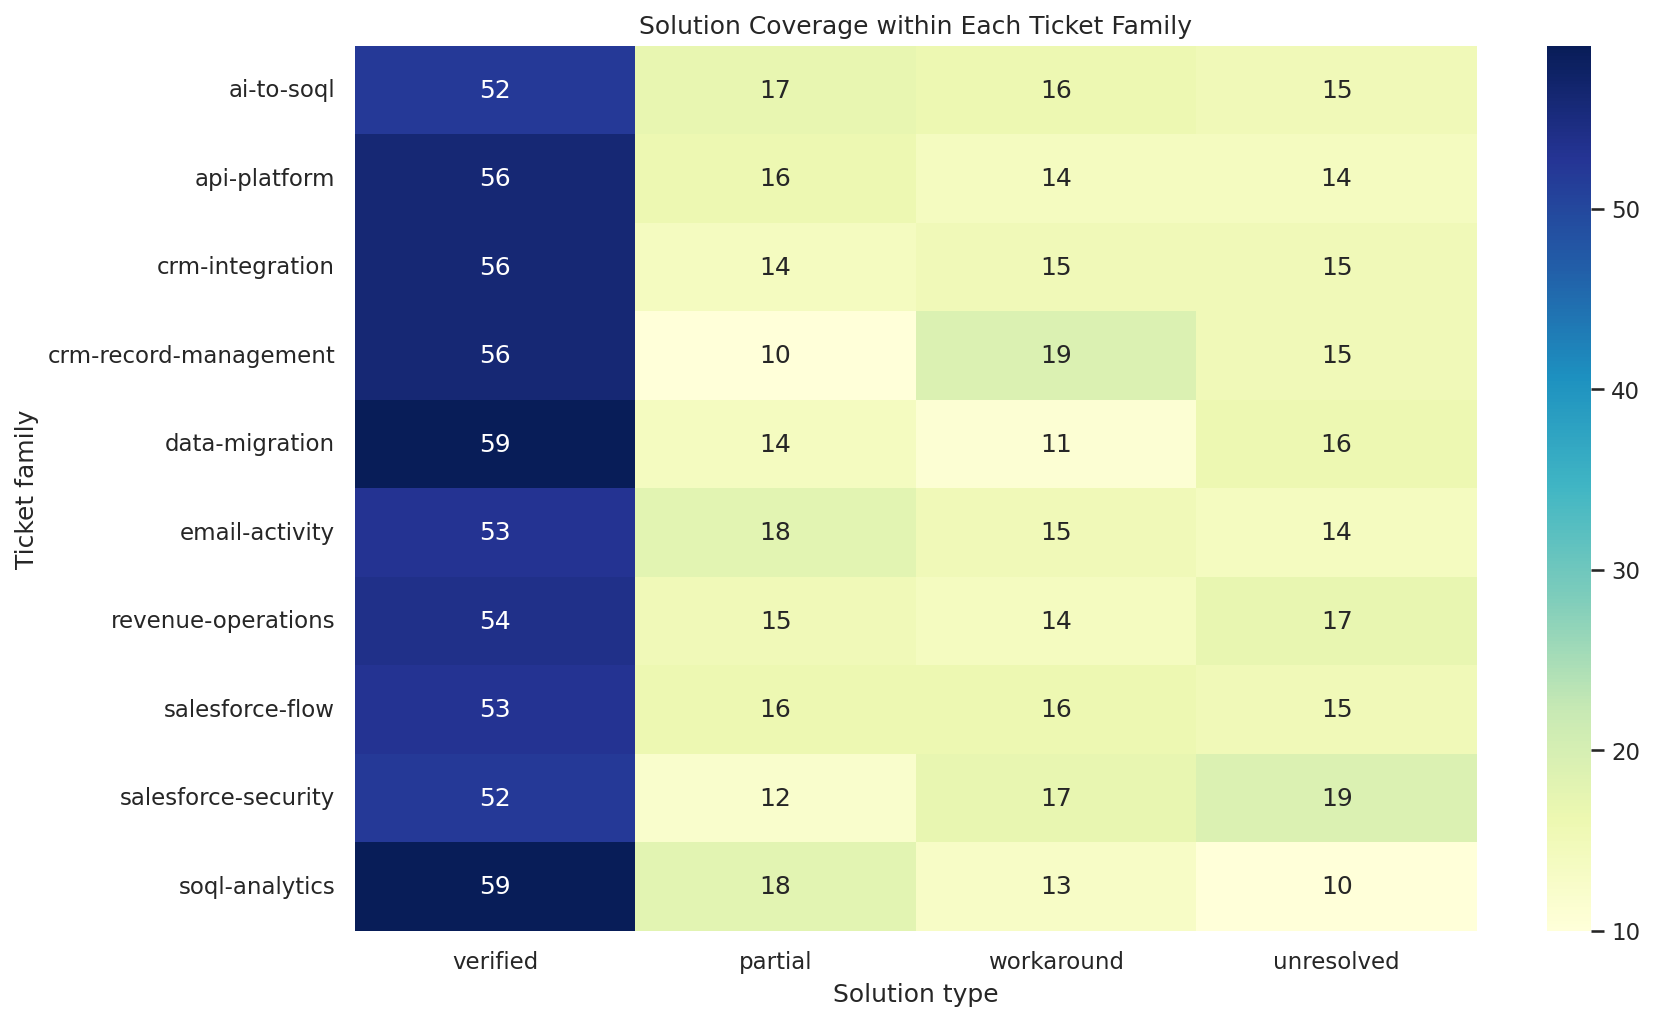

#### Workflow status versus solution quality

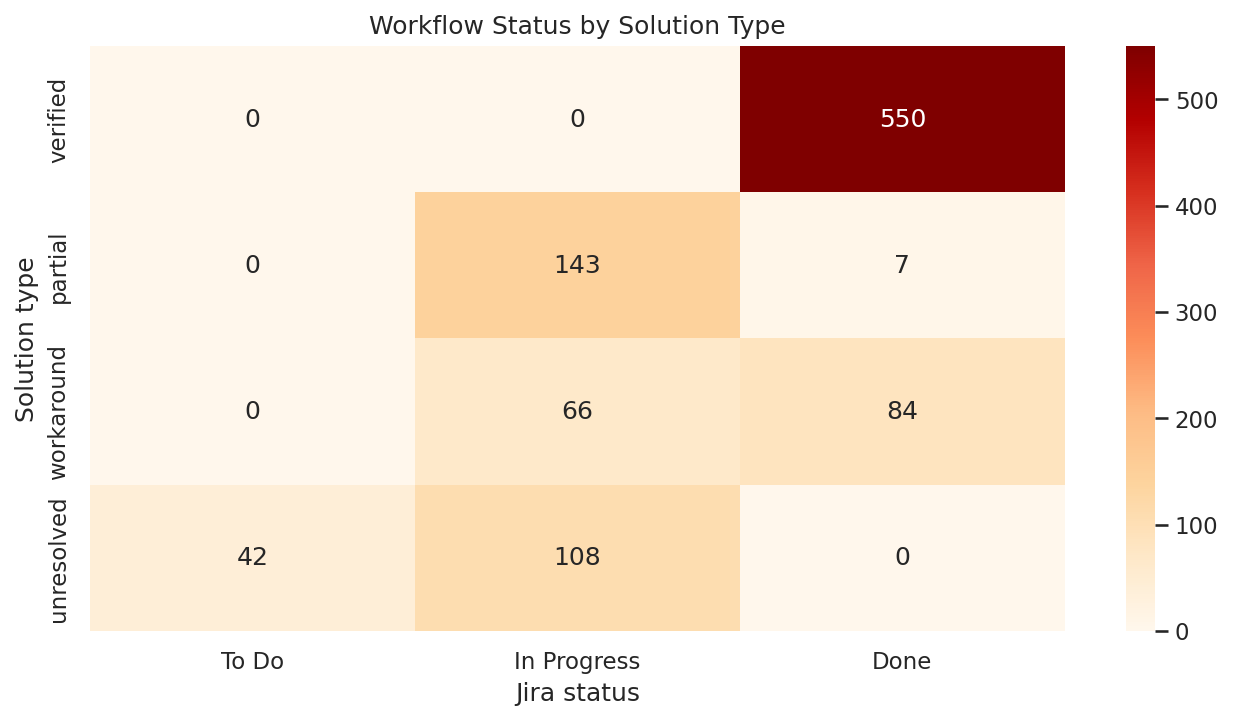

In [9]:
# 2.2 Display the focused overview and all saved figures.
overview_labels = {
    "tickets": "Tickets",
    "families": "Technical families",
    "solution_types": "Solution types",
    "unique_components": "Unique components",
    "open_tickets": "Open tickets",
    "done_tickets": "Done tickets",
}
overview_table = pd.DataFrame(
    [
        (overview_labels[key], value)
        for key, value in eda_summary["overview"].items()
    ],
    columns=["Measure", "Value"],
)
display(overview_table)

figure_titles = {
    "operational": "Operational dataset profile",
    "family_solution": "Solution coverage within each family",
    "status_solution": "Workflow status versus solution quality",
}
for figure_name, title in figure_titles.items():
    display(Markdown(f"#### {title}"))
    display(Image(filename=str(eda_artifact_paths[figure_name])))


### Interpretation and completion gate

The interpretation is calculated from the current EDA summary rather than
written as fixed dataset numbers. The completion gate verifies numeric
coverage, unchanged input schema, non-empty artifacts and Drive-only storage.


In [10]:
# 2.3 Derive the key findings and verify the completed EDA stage.
distributions = eda_summary["distributions"]
total_tickets = eda_summary["overview"]["tickets"]
high_priority = (
    distributions["Priority"]["Highest"]
    + distributions["Priority"]["High"]
)
findings = [
    f"{distributions['Work Type']['Bug']:,} of {total_tickets:,} records are Bugs.",
    f"{high_priority:,} tickets have High or Highest priority.",
    f"{eda_summary['overview']['open_tickets']:,} tickets are not in Done status.",
    "Status and solution type must remain separate: Done includes verified, "
    "partial and workaround records.",
    f"Component has {eda_summary['overview']['unique_components']:,} unique "
    "values, so it is useful as context or metadata but not as a split stratum.",
]
display(Markdown("\n".join(f"- {finding}" for finding in findings)))

if tuple(tickets_df.columns) != ORIGINAL_TICKETS_SCHEMA:
    raise RuntimeError("tickets_df schema changed during EDA")
for name, artifact_path in eda_artifact_paths.items():
    if not artifact_path.is_relative_to(ARTIFACT_ROOT):
        raise RuntimeError(f"EDA artifact escaped Drive storage: {name}")

save_run_metadata(
    "exploratory_data_analysis",
    {
        "action": eda_result["action"],
        "eda_version": EDA_VERSION,
        "canonical_sha256": canonical_sha256,
        "figures": list(figure_titles),
    },
)
print("✅ Section 2 complete: focused EDA verified and displayed.")


- 746 of 1,000 records are Bugs.
- 405 tickets have High or Highest priority.
- 359 tickets are not in Done status.
- Status and solution type must remain separate: Done includes verified, partial and workaround records.
- Component has 998 unique values, so it is useful as context or metadata but not as a split stratum.

[INFO] Run metadata: run_exploratory_data_analysis_latest.json
✅ Section 2 complete: focused EDA verified and displayed.


### Section 2 result

- The notebook now presents only operational and RAG-relevant distributions.
- Family/solution coverage supports the later stratified split and retrieval
  evaluation.
- Status and solution quality are shown as distinct signals that must both be
  available to the answer pipeline.
- High-cardinality `Component` remains useful for semantic context and
  metadata, but not as a primary aggregation or stratification field.
- Text-length plots and repeated QA evidence were removed from the main EDA.

The unchanged `tickets_df` can now proceed to deterministic splitting.


## 3. Deterministic and Leakage-Safe Dataset Splitting

### Goal and principle

This section freezes the 1,000 validated **tickets** into 750 Train, 150
Validation and 100 Test records using the configured seed and combined
`family + solution_type` stratum. Stratification preserves technical-domain
and solution-quality coverage without fragmenting the data across less stable
metadata combinations.

These are **ticket pools, not question sets**. Train provides evidence for
system development and later QLoRA examples; Validation supports model,
retrieval and prompt decisions; Test supplies protected evidence for final
evaluation questions. A later benchmark may select representative questions
from a split without turning every ticket in that split into a question.

Compatible split artifacts are loaded rather than rebuilt.


In [11]:
# 3.1 BUILD or LOAD the deterministic frozen split artifacts.
from IPython.display import Image, Markdown

from jirag.splitting import ensure_dataset_splits

SPLIT_VERSION = CONFIG["split_version"]
SPLIT_MANIFEST_PATH = PATHS["data_manifests"] / f"split_manifest_{SPLIT_VERSION}.json"
SPLIT_IDS_PATH = PATHS["data_manifests"] / f"split_ids_{SPLIT_VERSION}.json"
SPLIT_BALANCE_FIGURE_PATH = (
    PATHS["reports_figs"] / f"split_solution_balance_{SPLIT_VERSION}.png"
)
split_paths = {
    name: PATHS["data_splits"] / f"{name}_{SPLIT_VERSION}.csv"
    for name in ("train", "validation", "test")
}
split_artifact_paths = {
    **split_paths,
    "ids": SPLIT_IDS_PATH,
    "manifest": SPLIT_MANIFEST_PATH,
    "figure": SPLIT_BALANCE_FIGURE_PATH,
}

split_result = ensure_dataset_splits(
    tickets_df=tickets_df,
    canonical_sha256=canonical_sha256,
    config=CONFIG,
    artifact_paths=split_artifact_paths,
)
split_frames = split_result["frames"]
train_df = split_frames["train"]
validation_df = split_frames["validation"]
test_df = split_frames["test"]
split_manifest = split_result["manifest"]
split_evidence = split_result["evidence"]
source_ids = set(tickets_df["ticket_id"])
print(f"[INFO] Split artifact action: {split_result['action']}")


[INFO] Split artifact action: LOAD


### Split composition and executable evidence

The overview and integrity tables are calculated from the loaded split
DataFrames. The heatmap presents solution-type percentages, making small
allocation differences visible without displaying all 40 internal strata.


,Split,Tickets,Families,Solution Types,Family × Solution Strata
0,Full Dataset,1000,10,4,40
1,Train,750,10,4,40
2,Validation,150,10,4,40
3,Test,100,10,4,40


,Integrity check,Result
0,Pairwise overlapping IDs,0
1,Covered source IDs,1000 / 1000
2,Schema preserved,True
3,All strata present,True
4,Test frozen,True


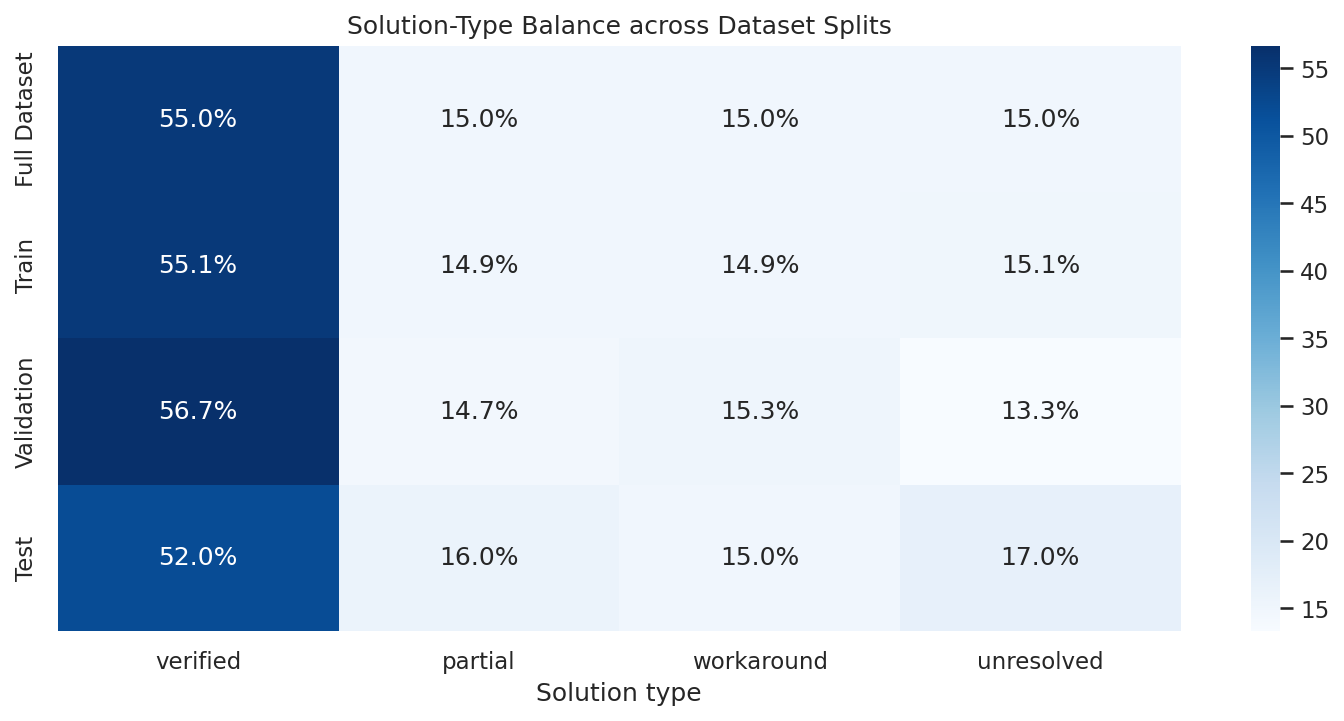

In [12]:
# 3.2 Display concise split composition, integrity and balance evidence.
split_labels = {
    "full_dataset": "Full Dataset",
    "train": "Train",
    "validation": "Validation",
    "test": "Test",
}
split_overview = pd.DataFrame(split_evidence["overview"])
split_overview["split"] = split_overview["split"].map(split_labels)
split_overview = split_overview.rename(
    columns={
        "split": "Split",
        "tickets": "Tickets",
        "families": "Families",
        "solution_types": "Solution Types",
        "strata": "Family × Solution Strata",
    }
)
display(split_overview)

integrity = split_evidence["integrity"]
integrity_table = pd.DataFrame(
    [
        ("Pairwise overlapping IDs", integrity["pairwise_overlap_ids"]),
        (
            "Covered source IDs",
            f"{integrity['covered_source_ids']} / {integrity['source_ids']}",
        ),
        ("Schema preserved", integrity["schema_preserved"]),
        ("All strata present", integrity["all_strata_present_in_every_split"]),
        ("Test frozen", integrity["test_frozen"]),
    ],
    columns=["Integrity check", "Result"],
)
display(integrity_table)
display(Image(filename=str(SPLIT_BALANCE_FIGURE_PATH)))


### Frozen-Test policy and completion gate

The manifest records the source fingerprint, split configuration, algorithm,
IDs and hashes of every persisted file. If the dataset or split settings
change, the existing Test set is not overwritten silently: a new
`split_version` is required. The Test rows must not influence retrieval,
prompt or model-selection decisions before final evaluation.


In [13]:
# 3.3 Report dynamic diagnostics and register the completed split stage.
diagnostics = split_evidence["diagnostics"]
max_solution_deviation = max(
    diagnostics["maximum_solution_percentage_point_deviation"].values()
)
max_stratum_error = max(
    diagnostics["maximum_stratum_allocation_error_tickets"].values()
)
findings = [
    "The three split ID sets are disjoint and cover the complete source dataset.",
    "Every split retains every observed family × solution-type stratum.",
    f"Maximum solution-share deviation is {max_solution_deviation:.2f} percentage points.",
    f"Maximum per-stratum allocation error is {max_stratum_error:.2f} tickets.",
    "Priority, Status and Work Type remain available for analysis, but are not "
    "added to the stratification key because sparse combinations would reduce stability.",
]
display(Markdown("\n".join(f"- {finding}" for finding in findings)))

for name, artifact_path in split_artifact_paths.items():
    if not artifact_path.is_relative_to(ARTIFACT_ROOT):
        raise RuntimeError(f"Split artifact escaped Drive storage: {name}")

save_run_metadata(
    "dataset_splitting",
    {
        "action": split_result["action"],
        "split_version": SPLIT_VERSION,
        "source_canonical_sha256": canonical_sha256,
        "manifest": SPLIT_MANIFEST_PATH.name,
    },
)
print("✅ Section 3 complete: deterministic splits validated and frozen.")


- The three split ID sets are disjoint and cover the complete source dataset.
- Every split retains every observed family × solution-type stratum.
- Maximum solution-share deviation is 3.00 percentage points.
- Maximum per-stratum allocation error is 0.75 tickets.
- Priority, Status and Work Type remain available for analysis, but are not added to the stratification key because sparse combinations would reduce stability.

[INFO] Run metadata: run_dataset_splitting_latest.json
✅ Section 3 complete: deterministic splits validated and frozen.


### Section 3 result

- The 1,000 approved tickets were split into 750 Train, 150 Validation and 100
  Test records using the versioned ratios, seed and family/solution stratum.
- These counts describe document pools; they do not imply 750 training
  questions, 150 Validation questions or 100 Test questions.
- Persisted split rows match their approved source records, remain pairwise
  disjoint and provide complete source coverage.
- Every observed stratum remains available in Train, Validation and Test.
- One compact balance figure replaces repeated distribution tables and report
  CSV files.
- The Test ticket pool is fingerprinted and protected from silent replacement.

The frozen split DataFrames are now ready for RAG-document construction.


## 4. Canonical RAG Document Construction

### Goal and design principle

This section converts every frozen ticket into one canonical RAG document.
The schema separates semantic retrieval, answer content, operational filters,
protected evaluation labels and system lineage. This prevents label leakage
while preserving the fields required for grounded answers and ticket citations.

| Document area | Stored fields | Purpose | Embedded |
|---|---|---|---:|
| `document_id` | `ticket_id` | Exact lookup and citation | No |
| `search` | Summary, Component and Description rendered as `embedding_text` | Semantic retrieval | Yes |
| `content` | Summary, Component and Description | Grounded answer generation | No separate vector |
| `metadata` | Component, Status, Priority and Work Type | Filtering and hybrid queries | No |
| `evaluation` | Family and solution type | Offline analysis without target leakage | No |
| `system` | Split and document version | Reproducibility and lineage | No |

`Component` is intentionally represented in both semantic text and metadata:
it helps match natural-language questions and also supports exact filtering.
The complete mapping is versioned in `configs/rag_document_contract.json`.


In [14]:
# 4.1 BUILD or LOAD the versioned RAG-document artifacts.
from jirag.documents import ensure_rag_documents, load_jsonl

RAG_DOCUMENT_CONTRACT_PATH = PATHS["configs"] / "rag_document_contract.json"
RAG_DOC_ROOT = PATHS["data_processed"] / CONFIG["rag_doc_version"]
DOC_PATHS = {
    name: RAG_DOC_ROOT / f"rag_documents_{name}_v1.jsonl"
    for name in ("train", "validation", "test")
}
DOC_MANIFEST_PATH = RAG_DOC_ROOT / "rag_documents_manifest_v1.json"
rag_document_artifact_paths = {
    **DOC_PATHS,
    "manifest": DOC_MANIFEST_PATH,
}

rag_document_result = ensure_rag_documents(
    split_frames=split_frames,
    split_manifest=split_manifest,
    contract_path=RAG_DOCUMENT_CONTRACT_PATH,
    artifact_paths=rag_document_artifact_paths,
)

# Public objects retained for the embedding and retrieval sections.
all_docs = rag_document_result["documents"]
manifest = rag_document_result["manifest"]
rag_document_contract = rag_document_result["contract"]
action = rag_document_result["action"]

print(f"[INFO] RAG-document artifact action: {action}")
if rag_document_result["manifest_upgraded"]:
    print("[INFO] Existing valid JSONL files were retained; their manifest was upgraded.")


[INFO] RAG-document artifact action: LOAD


### Executable integrity evidence

The completion gate does more than validate a JSON schema. Every persisted
document is reloaded and compared with the exact deterministic document built
from its source split row. It also verifies counts, unique IDs, split isolation,
source lineage and content fingerprints.

The embedding text is reconstructed only from the contract-approved content
fields. Status, Priority, Work Type, Family, solution type, ticket ID and split
therefore cannot enter the vector representation accidentally.


In [15]:
# 4.2 Display concise construction and integrity evidence.
integrity = rag_document_result["integrity"]
document_summary = pd.DataFrame(
    [
        {
            "Split": split_name.title(),
            "Source rows": len(split_frames[split_name]),
            "RAG documents": len(all_docs[split_name]),
            "Unique IDs": len({doc["document_id"] for doc in all_docs[split_name]}),
            "Source fingerprint": manifest["source_fingerprints"][split_name]["sha256"][:12],
            "Document fingerprint": manifest["output_fingerprints"][split_name][:12],
        }
        for split_name in ("train", "validation", "test")
    ]
)
display(document_summary)

integrity_summary = pd.DataFrame(
    [
        ("Every document matches its source row", integrity["documents_match_source_rows"]),
        ("Counts match frozen splits", integrity["counts_match_source"]),
        ("IDs are unique within each split", integrity["unique_ids_within_splits"]),
        ("Splits remain pairwise disjoint", integrity["pairwise_disjoint"]),
        (
            "Embedding uses approved fields only",
            integrity["embedding_uses_approved_fields_only"],
        ),
    ],
    columns=["Integrity check", "Result"],
)
display(integrity_summary)


,Split,Source rows,RAG documents,Unique IDs,Source fingerprint,Document fingerprint
0,Train,750,750,750,369c3d45c173,0efdfbf7140b
1,Validation,150,150,150,767e663b85c3,563e886fa907
2,Test,100,100,100,a6fedf5d33cd,d4c936138fae


,Integrity check,Result
0,Every document matches its source row,True
1,Counts match frozen splits,True
2,IDs are unique within each split,True
3,Splits remain pairwise disjoint,True
4,Embedding uses approved fields only,True


### Document preview and completion gate

The preview below is shortened only for notebook readability; the JSONL file
retains the complete ticket. The final gate confirms that all generated files
remain under Drive artifacts and records the completed stage for reproducibility.

After this stage, later sections consume the saved canonical documents rather
than rebuilding their own ticket representations.


In [16]:
# 4.3 Preview one document and register the completed stage.
from copy import deepcopy

sample_document = deepcopy(all_docs["train"][0])
preview_limit = 320
for container, field_name in (("search", "embedding_text"), ("content", "description")):
    value = sample_document[container][field_name]
    if len(value) > preview_limit:
        sample_document[container][field_name] = value[:preview_limit] + " ... [preview truncated]"
display(sample_document)

for name, artifact_path in rag_document_artifact_paths.items():
    if not artifact_path.is_relative_to(ARTIFACT_ROOT):
        raise RuntimeError(f"RAG-document artifact escaped Drive storage: {name}")

if sum(len(documents) for documents in all_docs.values()) != len(tickets_df):
    raise RuntimeError("RAG-document coverage differs from the approved dataset")

save_run_metadata(
    "rag_document_construction",
    {
        "action": action,
        "document_version": rag_document_contract["document_version"],
        "contract_version": rag_document_contract["contract_version"],
        "manifest": DOC_MANIFEST_PATH.name,
        "manifest_upgraded": rag_document_result["manifest_upgraded"],
    },
)
print("✅ Section 4 complete: canonical RAG documents validated and ready.")


{'document_id': 'tckt-0001',
 'search': {'embedding_text': 'Summary: Latest email engagement is not classified correctly on Lead and Contact\nComponent: Salesforce Email Automation\nDescription: CONTEXT\nSales teams need the latest email date, direction, and body visible on each Lead or Contact. Native messages and email Tasks are processed through separate flows.\n\nISSUE OR REQUES ... [preview truncated]'},
 'content': {'summary': 'Latest email engagement is not classified correctly on Lead and Contact',
  'component': 'Salesforce Email Automation',
  'description': 'CONTEXT\nSales teams need the latest email date, direction, and body visible on each Lead or Contact. Native messages and email Tasks are processed through separate flows.\n\nISSUE OR REQUEST\nInbound replies logged as Tasks are stamped as sent emails, making the latest engagement state unreliable.\n\nEXPECTED BEHAVIOR\nThe n ... [preview truncated]'},
 'metadata': {'component': 'Salesforce Email Automation',
  'status':

[INFO] Run metadata: run_rag_document_construction_latest.json
✅ Section 4 complete: canonical RAG documents validated and ready.


## 5. Embedding Model Selection for Vector Retrieval

### Core RAG component: choosing the vector representation

An embedding model converts each ticket and user question into vectors. Their
similarity determines which evidence reaches the answer model, so this is a
core RAG design decision rather than a text-generation experiment.

This section compares three candidate models under one reproducible protocol.
It uses only Train documents, manually reviewed query/gold pairs and each
model's required query/document prefixes. Gemma, answer generation, reranking
and the final Vector DB remain outside this stage.

The experiment is intentionally a balanced model-selection pilot, not the
final system evaluation. Retrieval on the complete corpus is evaluated later
using the frozen Validation and Test questions.


### 5.1 Versioned experiment and BUILD/LOAD contract

The model definitions and selection rules live in
`configs/embedding_selection_contract.json`; the 22 reviewed questions live in
`configs/embedding_pilot_queries.json`. Keeping them in Git makes the evidence
reviewable without embedding hundreds of data lines inside the notebook.

Results are built once and subsequently loaded only when the Train-document,
pilot, query and protocol fingerprints still match. A GPU is used when
available; saved results remain reusable on a CPU runtime.


In [17]:
# 5.1 BUILD or LOAD the embedding-model selection experiment.
from IPython.display import Image

from jirag.embedding_selection import (
    ensure_embedding_model_selection,
    representative_failures,
)

EMBEDDING_SELECTION_CONTRACT_PATH = (
    PATHS["configs"] / "embedding_selection_contract.json"
)
EMBEDDING_PILOT_QUERIES_PATH = PATHS["configs"] / "embedding_pilot_queries.json"
EMBEDDING_SELECTION_ROOT = (
    PATHS["reports_eval"].parent
    / "retrieval"
    / CONFIG["embedding_selection_version"]
)
EMBEDDING_SELECTION_ARTIFACTS = {
    "metrics": EMBEDDING_SELECTION_ROOT / "metrics.json",
    "rankings": EMBEDDING_SELECTION_ROOT / "rankings.jsonl",
    "figure": EMBEDDING_SELECTION_ROOT / "embedding_model_comparison.png",
    "manifest": EMBEDDING_SELECTION_ROOT / "manifest.json",
}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

embedding_selection_result = ensure_embedding_model_selection(
    train_documents=all_docs["train"],
    source_train_fingerprint=manifest["output_fingerprints"]["train"],
    config=CONFIG,
    contract_path=EMBEDDING_SELECTION_CONTRACT_PATH,
    queries_path=EMBEDDING_PILOT_QUERIES_PATH,
    artifact_paths=EMBEDDING_SELECTION_ARTIFACTS,
    device=DEVICE,
)

# Public objects retained by the full Vector DB stage.
EMBEDDING_CANDIDATES = embedding_selection_result["contract"]["models"]
comparison_metrics = embedding_selection_result["metrics"]
recommendation = embedding_selection_result["recommendation"]
selection_action = embedding_selection_result["action"]

print(f"[INFO] Embedding model-selection action: {selection_action}")
print(f"[INFO] Build device when required: {DEVICE}")


[INFO] Embedding model-selection action: LOAD
[INFO] Build device when required: cuda


### 5.2 Balanced Train-only evaluation design

Two tickets are selected deterministically from every
`family × solution_type` group. This produces 80 documents across all 40
groups, preventing the pilot from being dominated by verified solutions or a
single technical family. Status and Priority remain available in the documents
but are not sampling dimensions because they would create sparse groups.

Token diagnostics verify the Section 4 baseline
`one ticket = one document = one vector`: no evaluated ticket may be silently
truncated by a candidate model.


In [18]:
# 5.2 Display the experiment design and token-fit evidence.
selection_contract = embedding_selection_result["contract"]
experiment_design = pd.DataFrame(
    [
        ("Available Train documents", len(all_docs["train"])),
        ("Balanced pilot documents", len(embedding_selection_result["pilot_documents"])),
        ("Family × solution groups", selection_contract["sample"]["expected_groups"]),
        ("Documents per group", selection_contract["sample"]["documents_per_group"]),
        ("English questions", selection_contract["query_counts"]["en"]),
        ("Hebrew questions", selection_contract["query_counts"]["he"]),
        ("Saved ranking depth", selection_contract["ranking_top_k"]),
    ],
    columns=["Experiment element", "Value"],
)
display(experiment_design)

candidate_table = pd.DataFrame(
    [
        {
            "Candidate": model_key,
            "Model": model_config["model_name"],
            "Role": model_config["role"],
        }
        for model_key, model_config in EMBEDDING_CANDIDATES.items()
    ]
)
display(candidate_table)
display(embedding_selection_result["token_diagnostics"])


,Experiment element,Value
0,Available Train documents,750
1,Balanced pilot documents,80
2,Family × solution groups,40
3,Documents per group,2
4,English questions,16
5,Hebrew questions,6
6,Saved ranking depth,10


,Candidate,Model,Role
0,bge_base_en_v1_5,BAAI/bge-base-en-v1.5,English retrieval baseline
1,nomic_embed_text_v1_5,nomic-ai/nomic-embed-text-v1.5,English long-context candidate
2,multilingual_e5_base,intfloat/multilingual-e5-base,English candidate with Hebrew-to-English robus...


,model,maximum_tokens,model_limit,truncated_documents
0,bge_base_en_v1_5,286,512,0
1,nomic_embed_text_v1_5,290,8192,0
2,multilingual_e5_base,353,512,0


### 5.3 Retrieval metrics and comparison

For each question, the model ranks the 80 candidate tickets by cosine
similarity. The manually reviewed gold ticket provides objective evidence:

- **Hit@1:** the gold ticket is the first result.
- **Hit@3 / Hit@5:** the gold ticket appears within the first 3 or 5 results.
- **MRR:** averages `1 / rank`, rewarding models that place the first gold
  ticket closer to the top; a gold outside Top-10 contributes zero.

English is the primary project requirement. Hebrew tests useful
Hebrew-to-English retrieval robustness but affects selection only after an
English tie.


,Model,Language,Queries,Hit@1,Hit@3,Hit@5,MRR
0,bge_base_en_v1_5,overall,22,68.2%,86.4%,90.9%,0.784
1,bge_base_en_v1_5,en,16,93.8%,100.0%,100.0%,0.969
2,bge_base_en_v1_5,he,6,0.0%,50.0%,66.7%,0.292
3,nomic_embed_text_v1_5,overall,22,68.2%,77.3%,81.8%,0.742
4,nomic_embed_text_v1_5,en,16,87.5%,93.8%,100.0%,0.919
5,nomic_embed_text_v1_5,he,6,16.7%,33.3%,33.3%,0.271
6,multilingual_e5_base,overall,22,90.9%,100.0%,100.0%,0.955
7,multilingual_e5_base,en,16,93.8%,100.0%,100.0%,0.969
8,multilingual_e5_base,he,6,83.3%,100.0%,100.0%,0.917


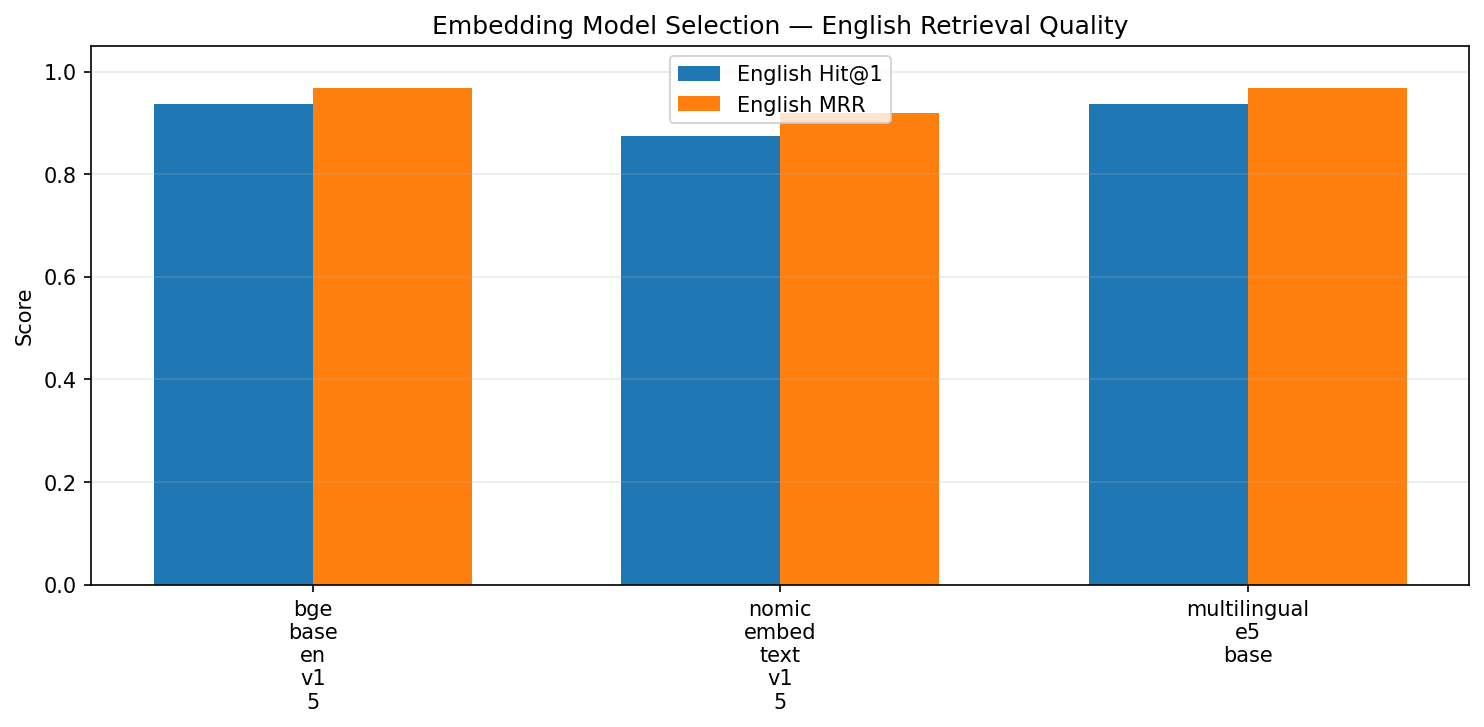

In [19]:
# 5.3 Compare retrieval quality and show one decision-focused graph.
metric_rows = []
for model_key, model_metrics in comparison_metrics.items():
    for language in ("overall", "en", "he"):
        metric_rows.append(
            {
                "Model": model_key,
                "Language": language,
                "Queries": model_metrics[language]["query_count"],
                "Hit@1": model_metrics[language]["hit_at_1"],
                "Hit@3": model_metrics[language]["hit_at_3"],
                "Hit@5": model_metrics[language]["hit_at_5"],
                "MRR": model_metrics[language]["mrr"],
            }
        )
comparison_table = pd.DataFrame(metric_rows)
comparison_display = comparison_table.copy()
for column in ("Hit@1", "Hit@3", "Hit@5"):
    comparison_display[column] = comparison_display[column].map(lambda value: f"{value:.1%}")
comparison_display["MRR"] = comparison_display["MRR"].map(lambda value: f"{value:.3f}")
display(comparison_display)
display(Image(filename=str(EMBEDDING_SELECTION_ARTIFACTS["figure"])))


### 5.4 Error evidence, selection rule and completion gate

The full Top-10 ranking for every model/query pair is retained in JSONL.
The notebook displays only a few mistakes made by the selected model so that
limitations remain visible without turning the main narrative into a long
error dump.

Selection is lexicographic: English Hit@5, MRR, Hit@3 and Hit@1 are compared
first; the equivalent Hebrew metrics are consulted only if the complete
English score is tied. This avoids an arbitrary weighted average and keeps the
project's English ticket corpus as the primary requirement.


In [20]:
# 5.4 Present the evidence-based decision and register the completed stage.
selected_model = recommendation["selected_model"]
selected_metrics = comparison_metrics[selected_model]
failure_examples = representative_failures(
    embedding_selection_result["rankings"],
    selected_model,
)
if failure_examples.empty:
    print("[INFO] The selected model ranked every pilot gold ticket first.")
else:
    display(failure_examples)

decision_table = pd.DataFrame(
    [
        ("Selected candidate", selected_model),
        ("Hugging Face model", EMBEDDING_CANDIDATES[selected_model]["model_name"]),
        ("Selection reason", recommendation["reason"]),
        ("English Hit@1", f"{selected_metrics['en']['hit_at_1']:.1%}"),
        ("English Hit@5", f"{selected_metrics['en']['hit_at_5']:.1%}"),
        ("English MRR", f"{selected_metrics['en']['mrr']:.3f}"),
        ("Hebrew used as tie-breaker", recommendation["used_hebrew_tiebreaker"]),
    ],
    columns=["Decision evidence", "Result"],
)
display(decision_table)

for name, artifact_path in EMBEDDING_SELECTION_ARTIFACTS.items():
    if not artifact_path.is_relative_to(ARTIFACT_ROOT):
        raise RuntimeError(f"Embedding-selection artifact escaped Drive storage: {name}")

save_run_metadata(
    "embedding_model_selection",
    {
        "action": selection_action,
        "experiment_version": selection_contract["experiment_version"],
        "selected_model": selected_model,
        "source_train_rag_fingerprint": manifest["output_fingerprints"]["train"],
    },
)
print(f"✅ Section 5 complete: selected embedding model {selected_model}.")


,Query,Language,Gold rank,Top result,Gold ticket
0,Q-EN-07,en,2,tckt-0364,tckt-0986
1,Q-HE-01,he,2,tckt-0679,tckt-0850


,Decision evidence,Result
0,Selected candidate,multilingual_e5_base
1,Hugging Face model,intfloat/multilingual-e5-base
2,Selection reason,English retrieval was tied; Hebrew-to-English ...
3,English Hit@1,93.8%
4,English Hit@5,100.0%
5,English MRR,0.969
6,Hebrew used as tie-breaker,True


[INFO] Run metadata: run_embedding_model_selection_latest.json
✅ Section 5 complete: selected embedding model multilingual_e5_base.


### Section 5 result

The selected embedding model is now justified by a reproducible retrieval
comparison rather than chosen by reputation alone. The result defines how
tickets and questions will be vectorized in Section 6, where the complete
1,000-ticket FAISS Vector DB is built.

Pilot scores measure model selection on a controlled Train subset; they must
not be reported as final RAG performance.


## 6. Core RAG Component — Persistent FAISS Vector Database

### Goal and architecture

Section 5 selected how text is represented as vectors. This section builds the
searchable **Vector DB** that connects a future user question to relevant Jira
evidence: all 1,000 canonical RAG documents are embedded once, indexed by
FAISS and persisted in Google Drive.

All Train, Validation and Test documents belong to the searchable knowledge
base. Dataset splits control which questions may guide development; they do
not hide valid organizational knowledge from retrieval. Protected evaluation
labels remain outside the embedded text.

The implementation uses temporary staging internally so an interrupted build
cannot be accepted as complete. Only fully reloaded and validated artifacts
are promoted, with the manifest written last. No persistent staging or backup
directory is created.


In [21]:
# 6.1 BUILD or LOAD the complete persistent Vector DB.
from sentence_transformers import SentenceTransformer  # Reused by Section 7 queries.

from jirag.vector_store import ensure_vector_store

SELECTED_MODEL_KEY = recommendation["selected_model"]
MODEL_CFG = EMBEDDING_CANDIDATES[SELECTED_MODEL_KEY]
VECTOR_STORE_CONTRACT_PATH = PATHS["configs"] / "vector_store_contract.json"
STORE_DIR = PATHS["vector_store"] / CONFIG["vector_store_version"]
STORE_ARTIFACTS = {
    "index": STORE_DIR / "faiss.index",
    "embeddings": STORE_DIR / "document_embeddings.npy",
    "mapping": STORE_DIR / "document_mapping.json",
    "manifest": STORE_DIR / "vector_store_manifest.json",
}

# The explicit alias prevents later stages from depending on a generic manifest name.
rag_document_manifest = manifest
vector_store_result = ensure_vector_store(
    documents_by_split=all_docs,
    rag_document_manifest=rag_document_manifest,
    selected_model_key=SELECTED_MODEL_KEY,
    model_config=MODEL_CFG,
    config=CONFIG,
    contract_path=VECTOR_STORE_CONTRACT_PATH,
    artifact_paths=STORE_ARTIFACTS,
    device=DEVICE,
)

# Public objects retained by the retrieval engine.
loaded_index = vector_store_result["index"]
loaded_embeddings = vector_store_result["embeddings"]
loaded_mapping = vector_store_result["mapping"]
loaded_manifest = vector_store_result["manifest"]
full_corpus = vector_store_result["corpus"]
current_corpus_fingerprint = vector_store_result["corpus_fingerprint"]
STORE_MODE = vector_store_result["action"]

vector_store_contract = vector_store_result["contract"]
EXPECTED_MODEL_NAME = vector_store_contract["model_name"]
EXPECTED_DOCUMENT_PREFIX = vector_store_contract["document_prefix"]
EXPECTED_QUERY_PREFIX = vector_store_contract["query_prefix"]
EXPECTED_EMBEDDING_DIM = vector_store_contract["embedding_dimension"]
EXPECTED_EMBEDDING_DTYPE = vector_store_contract["embedding_dtype"]
EXPECTED_INDEX_TYPE = vector_store_contract["index_type"]

print(f"[INFO] Vector DB action: {STORE_MODE}")
if vector_store_result["manifest_upgraded"]:
    print("[INFO] Existing vectors were retained; only the legacy manifest was upgraded.")


[INFO] Vector DB action: LOAD


### 6.2 Vector DB design decisions

`multilingual-e5-base` produces one normalized 768-dimensional vector per
ticket using its required `passage: ` prefix. FAISS stores them in
`IndexFlatIP`, an exact index appropriate for a 1,000-document corpus.

For unit-length vectors, inner product equals cosine similarity. We therefore
obtain exact cosine-equivalent search without an approximate-index tuning
stage. Embeddings may be generated on GPU, while the persisted FAISS index is
portable and searchable on CPU.


In [22]:
# 6.2 Display the active Vector DB contract and storage mapping.
vector_store_summary = pd.DataFrame(
    [
        ("Selected embedding model", EXPECTED_MODEL_NAME),
        ("Indexed documents", loaded_index.ntotal),
        ("Embedding dimensions", loaded_index.d),
        ("Embedding dtype", str(loaded_embeddings.dtype)),
        ("Normalized vectors", loaded_manifest["normalized"]),
        ("FAISS index", type(loaded_index).__name__),
        ("Similarity", "Cosine-equivalent normalized inner product"),
        ("Corpus fingerprint", current_corpus_fingerprint[:12]),
    ],
    columns=["Vector DB property", "Value"],
)
display(vector_store_summary)

mapping_preview = pd.DataFrame(
    [loaded_mapping[0], loaded_mapping[len(loaded_mapping) // 2], loaded_mapping[-1]]
)
display(mapping_preview)


,Vector DB property,Value
0,Selected embedding model,intfloat/multilingual-e5-base
1,Indexed documents,1000
2,Embedding dimensions,768
3,Embedding dtype,float32
4,Normalized vectors,True
5,FAISS index,IndexFlatIP
6,Similarity,Cosine-equivalent normalized inner product
7,Corpus fingerprint,21b0f96cd307


,vector_id,document_id,split
0,0,tckt-0001,train
1,500,tckt-0501,train
2,999,tckt-1000,train


### 6.3 Persistence and alignment evidence

The completion gate reloads the active index, NumPy matrix and mapping from
disk. It verifies their hashes, shapes, data types and normalization, compares
every mapping position with the sorted RAG corpus, and reconstructs all 1,000
FAISS vectors to confirm equality with the saved matrix.

This exhaustive round-trip check replaces the former self-vector smoke test,
which only proved that five stored vectors could retrieve themselves and did
not measure semantic retrieval quality. Real user-question retrieval begins in
Section 7.


In [23]:
# 6.3 Present executable integrity evidence and register the completed stage.
integrity = vector_store_result["integrity"]
integrity_table = pd.DataFrame(
    [
        ("Corpus count, IDs and split contract", integrity["corpus_contract_passed"]),
        ("Embedding shape, dtype and normalization", integrity["embedding_matrix_passed"]),
        ("Vector position maps to the correct ticket", integrity["mapping_alignment_passed"]),
        ("All FAISS vectors match the NumPy matrix", integrity["faiss_reconstruction_passed"]),
        ("Persisted files match manifest hashes", integrity["artifact_hashes_passed"]),
    ],
    columns=["Integrity check", "Result"],
)
display(integrity_table)

artifact_table = pd.DataFrame(
    [(name, path.name, str(path)) for name, path in STORE_ARTIFACTS.items()],
    columns=["Artifact", "File", "Drive path"],
)
display(artifact_table)

for name, artifact_path in STORE_ARTIFACTS.items():
    if not artifact_path.is_relative_to(ARTIFACT_ROOT):
        raise RuntimeError(f"Vector DB artifact escaped Drive storage: {name}")

save_run_metadata(
    "vector_store_generation",
    {
        "action": STORE_MODE,
        "vector_store_version": vector_store_contract["vector_store_version"],
        "model": SELECTED_MODEL_KEY,
        "corpus_fingerprint": current_corpus_fingerprint,
        "document_count": int(loaded_index.ntotal),
        "embedding_dimension": int(loaded_index.d),
        "index_type": type(loaded_index).__name__,
        "artifact_sha256": loaded_manifest["artifact_sha256"],
        "manifest_upgraded": vector_store_result["manifest_upgraded"],
    },
)
print("✅ Section 6 complete: persistent FAISS Vector DB validated and ready.")


,Integrity check,Result
0,"Corpus count, IDs and split contract",True
1,"Embedding shape, dtype and normalization",True
2,Vector position maps to the correct ticket,True
3,All FAISS vectors match the NumPy matrix,True
4,Persisted files match manifest hashes,True


,Artifact,File,Drive path
0,index,faiss.index,/content/drive/MyDrive/jiRAG/artifacts/vector_...
1,embeddings,document_embeddings.npy,/content/drive/MyDrive/jiRAG/artifacts/vector_...
2,mapping,document_mapping.json,/content/drive/MyDrive/jiRAG/artifacts/vector_...
3,manifest,vector_store_manifest.json,/content/drive/MyDrive/jiRAG/artifacts/vector_...


[INFO] Run metadata: run_vector_store_generation_latest.json
✅ Section 6 complete: persistent FAISS Vector DB validated and ready.


### Section 6 result

- All 1,000 tickets are represented by aligned, normalized E5 vectors.
- The exact FAISS index, NumPy matrix, ID mapping and lineage manifest are
  persistent and fingerprinted.
- Compatible runs use LOAD without re-encoding; an earlier valid store can be
  retained through a metadata-only manifest upgrade.
- No smoke-test result is presented as retrieval quality.

Section 7 can now embed a real user question, search this Vector DB and return
the most relevant ticket evidence.


## 7. Core RAG Component — Retrieval Engine

The **retrieval engine** converts a natural-language question into relevant Jira evidence. It embeds the question with the same E5 model contract used for the documents, searches the persistent FAISS Vector DB, and maps the highest-scoring vectors back to complete tickets.

Semantic retrieval is the experimental core of this section. Exact lookup, metadata filtering and aggregation are retained as deterministic product capabilities for questions that do not require vector search. Hybrid retrieval combines a semantic topic with explicit metadata constraints. A later Router will select among these tools automatically; Section 7 defines and validates the tools themselves.


In [24]:
# 7.1 Create one retrieval interface over the validated Section 6 artifacts.
import copy  # Retained for the existing generation sections below.

from jirag.retrieval import (
    RetrievalEngine,
    load_retrieval_contract,
    results_to_dataframe,
    validate_positive_integer,
)

retrieval_contract = load_retrieval_contract(
    PATHS["configs"] / "retrieval_contract.json"
)
retrieval_engine = RetrievalEngine(
    index=loaded_index,
    embeddings=loaded_embeddings,
    mapping=loaded_mapping,
    documents=full_corpus,
    model_config=MODEL_CFG,
    vector_contract=vector_store_contract,
    retrieval_contract=retrieval_contract,
    device=DEVICE,
)

# Temporary compatibility aliases keep the existing Sections 8–13 executable.
faiss_index = retrieval_engine.index
document_embeddings = retrieval_engine.embeddings
document_mapping = retrieval_engine.mapping
indexed_documents = retrieval_engine.documents
index_manifest = loaded_manifest
document_by_id = retrieval_engine.document_by_id
document_position_by_id = retrieval_engine.document_position_by_id
semantic_search = retrieval_engine.semantic_search
lookup_ticket = retrieval_engine.lookup_ticket
filter_tickets = retrieval_engine.filter_tickets
aggregate_tickets = retrieval_engine.aggregate_tickets
hybrid_search = retrieval_engine.hybrid_search
get_query_encoder = retrieval_engine.get_query_encoder
encode_query = retrieval_engine.encode_query
validate_ranked_results = retrieval_engine.validate_ranked_results
format_retrieval_result = retrieval_engine.format_result
results_to_df = results_to_dataframe

print(f"[INFO] Retrieval engine ready for {len(indexed_documents)} tickets.")


[INFO] Retrieval engine ready for 1000 tickets.


### 7.2 Semantic retrieval from the Vector DB

E5 applies different prefixes to the two sides of retrieval: the stored tickets were embedded as `passage: ...`, while a user question is embedded as `query: ...`. Both vectors are L2-normalized, so FAISS `IndexFlatIP` returns exact cosine-equivalent similarity scores.

`top_k` controls how many candidate sources are returned. A higher score means greater vector similarity, not a probability or proof of factual correctness. Formal retrieval quality is therefore measured later against the frozen gold evaluation set.


In [25]:
# 7.2 Retrieve evidence for a realistic managerial question.
semantic_question = (
    "Were employees able to access sensitive supplier information, "
    "and if so, how was the exposure resolved?"
)
semantic_example_results = semantic_search(semantic_question, top_k=5)

semantic_preview = results_to_df(semantic_example_results)[
    ["rank", "document_id", "score", "summary", "component", "status", "priority"]
]
display(semantic_preview)


[INFO] Loading query encoder: intfloat/multilingual-e5-base on cuda...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

,rank,document_id,score,summary,component,status,priority
0,1,tckt-0186,0.8185,A custom object left at public read exposes in...,Sharing Defaults Review,Done,High
1,2,tckt-0786,0.8177,A scheduled report export job that bypasses ro...,Template Change Exposed Internal Field,Done,Highest
2,3,tckt-0586,0.8099,A hardcoded integration key was found in a cli...,Exposed Credential In Client Code,Done,Highest
3,4,tckt-0290,0.8072,Protected identifiers are written in clear tex...,Sensitive Data In Logs,Done,Highest
4,5,tckt-0286,0.8067,A refreshed sandbox exposes live customer cont...,Sandbox Data Protection,Done,Highest


### 7.3 Deterministic retrieval and hybrid search

Not every managerial question should use embeddings:

- **Exact lookup** resolves an explicit ticket reference. The small normalizer accepts forms such as `tckt-0186`, `TCKT-186`, `ticket 186` and `טיקט 186`.
- **Filtering and aggregation** answer exact operational questions such as how many high-priority tickets remain open.
- **Hybrid retrieval** first applies exact metadata constraints and then ranks only the eligible tickets semantically.

Operational filters use ID, component, status, priority, work type and open/closed state. `family`, `solution_type` and `split` remain available internally for controlled evaluation, but they are not presented as ordinary user-facing business filters.


In [26]:
# 7.3 One concise example of each complementary retrieval path.
lookup_example = lookup_ticket("טיקט 186")
high_open_summary = aggregate_tickets(
    filters={"priority": "High", "is_open": True},
    group_by="status",
)
hybrid_example_results = hybrid_search(
    query="customer records were deleted unexpectedly",
    filters={"priority": "High", "is_open": True},
    top_k=3,
)

print("Exact lookup after ID normalization:")
display(results_to_df([lookup_example])[["document_id", "summary", "status"]])
print("Exact aggregation of open High-priority tickets:")
display(pd.DataFrame([high_open_summary]))
print("Hybrid retrieval: semantic topic within the filtered subset:")
display(
    results_to_df(hybrid_example_results)[
        ["rank", "document_id", "score", "summary", "status", "priority"]
    ]
)


Exact lookup after ID normalization:


,document_id,summary,status
0,tckt-0186,A custom object left at public read exposes in...,Done


Exact aggregation of open High-priority tickets:


,filters,total,group_by,grouped_counts,sample_document_ids
0,"{'priority': 'High', 'is_open': True}",92,[status],"{'In Progress': 85, 'To Do': 7}","[tckt-0012, tckt-0028, tckt-0033, tckt-0040, t..."


Hybrid retrieval: semantic topic within the filtered subset:


,rank,document_id,score,summary,status,priority
0,1,tckt-0420,0.8606,Retention deletion covers cases but not their ...,In Progress,High
1,2,tckt-0761,0.8328,A source system's soft-deleted records were mi...,In Progress,High
2,3,tckt-0263,0.8325,Load throughput collapses from the third wave ...,In Progress,High


### 7.4 Focused completion gate

Section 6 already performed exhaustive persistence and alignment validation. This gate checks only the new retrieval boundary: ranked FAISS results, normalized lookup, exact aggregation and enforcement of hybrid filters. It verifies implementation mechanics without treating a demonstration query as an accuracy measurement.


In [27]:
# 7.4 Validate the new retrieval boundary and record reproducibility evidence.
direct_high_open = filter_tickets({"priority": "High", "is_open": True})

retrieval_checks = {
    "filter_aggregation_parity": len(direct_high_open) == high_open_summary["total"],
    "semantic_ranking": validate_ranked_results(semantic_example_results),
    "normalized_lookup": lookup_example["document_id"] == "tckt-0186",
    "aggregation_consistency": (
        sum(high_open_summary["grouped_counts"].values())
        == high_open_summary["total"]
    ),
    "hybrid_filter_enforcement": (
        bool(hybrid_example_results)
        and validate_ranked_results(
            hybrid_example_results,
            expected_filters={"priority": "High", "is_open": True},
        )
    ),
    "query_encoder_cached": (
        get_query_encoder() is get_query_encoder()
    ),
}
RETRIEVAL_VALIDATION_PASSED = all(retrieval_checks.values())
if not RETRIEVAL_VALIDATION_PASSED:
    raise RuntimeError(f"Section 7 validation failed: {retrieval_checks}")

retrieval_summary = pd.DataFrame(
    [
        ("Semantic search", "FAISS over the complete corpus"),
        ("Exact lookup", lookup_example["document_id"]),
        ("Structured aggregation", high_open_summary["total"]),
        ("Hybrid search", f"{len(hybrid_example_results)} filtered results"),
        ("Validation", "Passed"),
    ],
    columns=["Capability", "Evidence"],
)
display(retrieval_summary)

save_run_metadata(
    "retrieval_engine_validation",
    {
        "retrieval_contract_version": retrieval_contract["contract_version"],
        "model": SELECTED_MODEL_KEY,
        "model_name": vector_store_contract["model_name"],
        "query_prefix": vector_store_contract["query_prefix"],
        "corpus_size": len(indexed_documents),
        "embedding_dimension": faiss_index.d,
        "index_type": type(faiss_index).__name__,
        "validation_checks": retrieval_checks,
        "validation_passed": RETRIEVAL_VALIDATION_PASSED,
    },
)
print("✅ Section 7 complete: retrieval tools validated and ready for grounded generation.")


,Capability,Evidence
0,Semantic search,FAISS over the complete corpus
1,Exact lookup,tckt-0186
2,Structured aggregation,92
3,Hybrid search,3 filtered results
4,Validation,Passed


[INFO] Run metadata: run_retrieval_engine_validation_latest.json
✅ Section 7 complete: retrieval tools validated and ready for grounded generation.


### Section 7 result

- **Core RAG retrieval:** natural-language questions are embedded with the selected E5 query contract and searched against the persistent FAISS Vector DB.
- **Stable evidence schema:** every ranked result contains the ticket content and metadata required by the generation and evaluation stages.
- **Complementary product tools:** normalized ID lookup, exact filtering, aggregation and filtered semantic search remain available without being misrepresented as Vector DB experiments.
- **Clean implementation:** reusable logic lives in `src/jirag/retrieval.py`; the former 181-line smoke suite and duplicate Section 6 validation were removed.
- **Quality boundary:** this section proves correct retrieval mechanics. Sections 9–12 perform frozen-gold quality evaluation and reranking.


## 8. Core RAG Pipeline — Retrieval, Grounded Generation and Baseline Prompt Engineering

Section 7 returned ranked Jira evidence. This section completes the baseline **Retrieval-Augmented Generation (RAG)** pipeline: a user question is retrieved semantically, converted into a controlled evidence context, and passed to Gemma 4 under a versioned grounding prompt.

The language model is used as a synthesizer rather than as the source of truth. Material claims must be supported by retrieved tickets and cited as `[tckt-XXXX]`. This section establishes one clean baseline; the later consolidated experiment will compare it with improved retrieval, reranking and Prompt Engineering.


In [28]:
# 8.1 Load the versioned generation and Prompt Engineering contracts.
import importlib.metadata  # Temporary dependency of the existing evaluation sections.
import time  # Temporary dependency of the existing evaluation sections.

from IPython.display import Markdown

from jirag.generation import (
    GroundedGenerator,
    build_generation_identity,
    ensure_generation_artifact,
    load_generation_contract,
    load_system_prompt,
    validate_citations,
    validate_grounded_result,
)

generation_contract = load_generation_contract(
    PATHS["configs"] / "generation_contract.json"
)
baseline_system_prompt, baseline_prompt_sha256 = load_system_prompt(
    PATHS["configs"],
    generation_contract,
)
grounded_generator = GroundedGenerator(
    contract=generation_contract,
    system_prompt=baseline_system_prompt,
)

# Compatibility keys and wrappers remain until Sections 9–13 are consolidated.
CONFIG.update({
    "generation_model_id": generation_contract["model_id"],
    "generation_prompt_version": generation_contract["prompt_version"],
    "default_rag_top_k": generation_contract["default_top_k"],
    "max_rag_input_tokens": generation_contract["max_input_tokens"],
    "max_rag_new_tokens": generation_contract["max_new_tokens"],
})


def load_generation_model(model_id=CONFIG["generation_model_id"]):
    if model_id != generation_contract["model_id"]:
        raise ValueError("Requested model differs from the generation contract")
    return grounded_generator.load_model()


def build_rag_messages(question, context_text):
    return grounded_generator.build_messages(question, context_text)


def generate_grounded_answer(
    question,
    retrieval_results,
    max_new_tokens=CONFIG["max_rag_new_tokens"],
):
    return grounded_generator.generate(
        question,
        retrieval_results,
        message_builder=build_rag_messages,
        max_new_tokens=max_new_tokens,
        prompt_version=CONFIG["generation_prompt_version"],
    )


def answer_with_rag(
    question,
    top_k=CONFIG["default_rag_top_k"],
    max_new_tokens=CONFIG["max_rag_new_tokens"],
):
    evidence = semantic_search(question, top_k=top_k)
    return generate_grounded_answer(question, evidence, max_new_tokens)


### 8.2 Baseline Prompt Engineering and evidence context

The baseline prompt is a controlled part of the RAG system, not an informal instruction hidden inside a function. It requires grounded answers, local ticket citations, explicit uncertainty, same-language responses and careful resolution wording. A `Done` status alone is not treated as proof of a permanent fix.

The context contains only fields that can support the answer: ticket ID, summary, component, work type, status, priority and description. Evaluation labels (`family`, `solution_type`, `split`) are excluded to prevent Gold-label leakage. Retrieval rank and similarity score are also excluded because they describe the search process rather than the incident itself.


In [29]:
# 8.2 Display the reproducible baseline contract without exposing hidden runtime state.
generation_summary = pd.DataFrame(
    [
        ("Generation model", generation_contract["model_id"]),
        ("Prompt version", generation_contract["prompt_version"]),
        ("Retrieved sources", generation_contract["default_top_k"]),
        ("Maximum input tokens", generation_contract["max_input_tokens"]),
        ("Maximum generated tokens", generation_contract["max_new_tokens"]),
        ("Deterministic decoding", not generation_contract["do_sample"]),
        ("Context fields", ", ".join(generation_contract["context_fields"])),
        (
            "Excluded fields",
            ", ".join(generation_contract["excluded_context_fields"]),
        ),
    ],
    columns=["Baseline RAG property", "Value"],
)
display(generation_summary)


,Baseline RAG property,Value
0,Generation model,google/gemma-4-E4B-it
1,Prompt version,basic_grounded_rag_v2_no_gold_labels
2,Retrieved sources,3
3,Maximum input tokens,12000
4,Maximum generated tokens,320
5,Deterministic decoding,True
6,Context fields,"ticket_id, summary, component, work_type, stat..."
7,Excluded fields,"family, solution_type, split, retrieval_score,..."


### 8.3 End-to-end baseline RAG with BUILD/LOAD

The same supplier-exposure question used in Section 7 now continues through generation. Reusing one question makes the distinction visible: Section 7 evaluated which evidence was retrieved, while Section 8 demonstrates how Gemma turns that evidence into a natural grounded answer.

The fixed demonstration is generated once and saved in Drive. Later compatible runs use `LOAD` and do not reload Gemma. A changed question, prompt, model, retrieved source list or corpus fingerprint invalidates the saved identity and triggers `BUILD`. New interactive questions are still generated live.


In [30]:
# 8.3 Retrieve the evidence and BUILD or LOAD one stable baseline answer.
baseline_question = (
    "Were employees able to access sensitive supplier information, "
    "and if so, how was the exposure resolved?"
)
baseline_retrieval_results = semantic_search(
    baseline_question,
    top_k=generation_contract["default_top_k"],
)
baseline_identity = build_generation_identity(
    question=baseline_question,
    retrieved_ticket_ids=[
        result["document_id"] for result in baseline_retrieval_results
    ],
    corpus_fingerprint=current_corpus_fingerprint,
    prompt_sha256=baseline_prompt_sha256,
    contract=generation_contract,
)
BASELINE_GENERATION_PATH = (
    PATHS["reports_generation"]
    / generation_contract["prompt_version"]
    / "baseline_demo.json"
)
baseline_rag_result, BASELINE_GENERATION_MODE = ensure_generation_artifact(
    BASELINE_GENERATION_PATH,
    baseline_identity,
    lambda: generate_grounded_answer(
        baseline_question,
        baseline_retrieval_results,
    ),
    result_validator=lambda result: validate_grounded_result(
        result, generation_contract
    )["passed"],
)
print(f"[INFO] Baseline RAG action: {BASELINE_GENERATION_MODE}")


[INFO] Baseline RAG action: LOAD


### 8.4 Grounded answer and source traceability

The answer is shown as a user-facing response rather than as a dump of the context fields. The source table remains visible below it so every citation can be traced back to the retrieved Jira evidence.


In [31]:
# 8.4 Present the generated answer, its sources and structural grounding evidence.
display(Markdown(f"**Question:** {baseline_rag_result['question']}"))
display(Markdown(f"**Grounded answer:** {baseline_rag_result['answer']}"))

baseline_sources = results_to_df(baseline_rag_result["retrieval_results"])[
    ["rank", "document_id", "score", "summary", "status", "priority"]
]
display(baseline_sources)

baseline_validation = validate_grounded_result(
    baseline_rag_result,
    generation_contract,
)
validation_table = pd.DataFrame(
    [
        (name.replace("_", " ").title(), passed)
        for name, passed in baseline_validation["checks"].items()
    ],
    columns=["Grounding check", "Passed"],
)
display(validation_table)
print("Cited tickets:", baseline_validation["citations"]["cited_ticket_ids"])


**Question:** Were employees able to access sensitive supplier information, and if so, how was the exposure resolved?

**Grounded answer:** Yes, employees were able to access sensitive supplier information because a custom object, which contained commercial terms from a supplier agreement, remained set to public read from a pilot [tckt-0186].

The exposure was resolved by setting the default access to private, implementing a sharing rule for the procurement group, and adding a criteria-based rule for approvers [tckt-0186]. Additionally, the go-live checklist was updated to require an explicit sharing decision for every object [tckt-0186]. Validation confirmed that users outside procurement received no results for the object in reports and search, while procurement retained full access [tckt-0186].

,rank,document_id,score,summary,status,priority
0,1,tckt-0186,0.8185,A custom object left at public read exposes in...,Done,High
1,2,tckt-0786,0.8177,A scheduled report export job that bypasses ro...,Done,Highest
2,3,tckt-0586,0.8099,A hardcoded integration key was found in a cli...,Done,Highest


,Grounding check,Passed
0,Non Empty Answer,True
1,Valid Citation Present,True
2,All Citations From Context,True
3,Token Budget Respected,True
4,Context Schema Enforced,True
5,Model Contract Matched,True


Cited tickets: ['tckt-0186']


### 8.5 Focused completion gate

These checks establish structural grounding: the answer exists, citations come from retrieved sources, the token budget is respected, protected evaluation fields are excluded and the configured model is recorded. They do not claim that every answer is factually complete; formal retrieval and generation quality belong to the consolidated evaluation experiment.


In [32]:
# 8.5 Block an invalid baseline and record one stable stage result.
if not baseline_validation["passed"]:
    raise RuntimeError(
        f"Section 8 grounding validation failed: {baseline_validation['checks']}"
    )
if baseline_rag_result["retrieved_ticket_ids"] != baseline_identity[
    "retrieved_ticket_ids"
]:
    raise RuntimeError("Saved baseline sources do not match the current retrieval")

save_run_metadata(
    "baseline_grounded_rag",
    {
        "action": BASELINE_GENERATION_MODE,
        "artifact": str(BASELINE_GENERATION_PATH),
        "artifact_identity": baseline_identity["fingerprint"],
        "model_id": generation_contract["model_id"],
        "prompt_version": generation_contract["prompt_version"],
        "prompt_sha256": baseline_prompt_sha256,
        "retrieved_ticket_ids": baseline_rag_result["retrieved_ticket_ids"],
        "citation_validation": baseline_validation["citations"],
        "grounding_checks": baseline_validation["checks"],
    },
)
print("✅ Section 8 complete: baseline RAG and Prompt Engineering validated.")


[INFO] Run metadata: run_baseline_grounded_rag_latest.json
✅ Section 8 complete: baseline RAG and Prompt Engineering validated.


### Section 8 result

- **Complete baseline RAG:** semantic retrieval now feeds a token-controlled evidence context into Gemma 4 and returns a natural answer with ticket citations.
- **Prompt Engineering:** the versioned baseline prompt defines grounding, uncertainty, resolution language, citations and response style.
- **Leakage protection:** Gold evaluation labels, retrieval scores and source ranks never enter the generation context.
- **Efficient reruns:** the fixed demonstration uses one identity-validated BUILD/LOAD artifact instead of repeated GPU smoke tests and timestamped files.
- **Clean implementation:** model loading, context construction, generation, citation checks and persistence live in `src/jirag/generation.py`.
- **Next consolidation:** the historical Sections 9–13 will be audited together and reduced to one or two focused sections comparing Baseline RAG with the selected improved retrieval, reranking and prompt pipeline.


## 9. Frozen Evaluation Benchmark and Protocol

### Why this section exists

A RAG demonstration can look convincing even when the correct source is
missing. This section therefore freezes a human-reviewed **question
benchmark**, which is distinct from the ticket split created in Section 3.

The benchmark contains 44 realistic managerial questions: 24 Validation
questions for development and 20 Test questions for final measurement. The
20-question Test benchmark contains 16 single-ticket, two multi-ticket and two
no-answer scenarios; four questions are in Hebrew. Its answerable questions
reference 16 unique Test tickets because several Hebrew questions deliberately
reuse English-question sources to test cross-lingual retrieval.

The 100-ticket Test split remains the protected source pool, but the benchmark
does **not** create one question for every Test ticket. The 20 questions are a
controlled POC sample rather than an exhaustive evaluation of all 100 Test
tickets. All 1,000 tickets remain searchable in the production-like Vector DB,
so non-Gold tickets from every split act as realistic retrieval competitors.

The **Gold ticket IDs** identify the Test or Validation evidence that should
support an answer. **Expected answer points** describe the facts a grounded
answer should cover. Neither is passed to FAISS, the reranker or Gemma.


In [33]:
# 9.1 Load and validate the versioned Gold benchmark.
from jirag.evaluation import (
    BGEReranker,
    ensure_generated_answers,
    ensure_retrieval_contexts,
    evaluate_retrieval_contexts,
    fingerprint,
    load_evaluation_contract,
    load_gold_benchmark,
    score_generation,
    select_retriever,
    write_jsonl,
)

evaluation_contract = load_evaluation_contract(
    PATHS["configs"] / "evaluation" / "unified_rag_evaluation_v1.json"
)
gold_records = load_gold_benchmark(
    PATHS["configs"] / "evaluation" / "gold_queries_v1.json",
    indexed_documents,
)
validation_gold = [r for r in gold_records if r["evaluation_split"] == "validation"]
test_gold = [r for r in gold_records if r["evaluation_split"] == "test"]

benchmark_summary = pd.DataFrame([
    {
        "split": split,
        "questions": len(rows),
        "single-ticket": sum(r["query_type"] == "single_ticket" for r in rows),
        "multi-ticket": sum(r["query_type"] == "multi_ticket" for r in rows),
        "no-answer": sum(r["answerability"] == "no_answer" for r in rows),
        "Hebrew": sum(r["language"] == "he" for r in rows),
    }
    for split, rows in (("Validation", validation_gold), ("Test (locked)", test_gold))
])
display(benchmark_summary)
assert len(gold_records) == 44 and len(validation_gold) == 24 and len(test_gold) == 20
print("✅ Frozen benchmark validated; Test remains locked.")

,split,questions,single-ticket,multi-ticket,no-answer,Hebrew
0,Validation,24,20,2,2,4
1,Test (locked),20,16,2,2,4


✅ Frozen benchmark validated; Test remains locked.


### 9.2 Evaluation boundaries

The evaluation units must not be confused:

| Object | Size | Role |
|---|---:|---|
| Dataset | 1,000 tickets | Complete organizational knowledge base |
| Frozen splits | 750 / 150 / 100 tickets | Control development and evidence provenance |
| Vector DB corpus | 1,000 tickets | Search space for every benchmark question |
| Validation benchmark | 24 questions | Select retrieval and prompt improvements |
| Test benchmark | 20 questions | Report final performance after freezing the system |

- **Validation** may compare the baseline with focused improvements and select
  the final configuration.
- **Test** is evaluated only after the retriever, prompt and metric thresholds
  are frozen. Its results are reported, not used for another tuning loop.
- **Lookup, filtering and aggregation** are exact product tools, so Section 7
  validates them with deterministic assertions rather than semantic Hit/MRR.
- **No-answer questions** have no Gold ticket by design. They measure whether
  generation abstains rather than whether retrieval found a source.
- **Hebrew questions** are a small robustness slice, not the sole reason for
  choosing a multilingual embedding model.

The reviewed benchmark definitions live in Git; generated contexts, answers
and metric reports live in Drive.


### Section 9 result

The project now has one immutable, leakage-safe benchmark and one evaluation
protocol shared by retrieval, reranking, Prompt Engineering and the later
QLoRA comparison. The benchmark is deliberately question-based: 24 Validation
questions guide selection, while 20 Test questions measure the frozen system
against Gold evidence drawn only from the Test split.


## 10. Unified RAG Evaluation, Improvement and Final Test

This section combines retrieval, reranking, Prompt Engineering and generation
evaluation into one controlled sequence:

1. The 24 Validation questions compare the two RAG variants.
2. Validation selects the retriever and prompt; Test does not influence this
   decision.
3. The complete selected-system contract is fingerprinted and frozen.
4. Only then are the 20 Test questions evaluated and reported.

The compared variants are:

- **Baseline RAG:** E5 semantic Top-5 + baseline grounding prompt + Gemma.
- **Improved RAG:** E5 Top-10 candidates → BGE cross-encoder reranking → Top-5
  + improved Prompt v3 + the same Gemma.

The reranker reads each question together with each candidate ticket, so it
can order close candidates more precisely than vector similarity alone.
Prompt v3 then asks Gemma to prefer direct evidence, answer all supported
parts, separate similar incidents and cite claims locally. Because the Gemma
model is unchanged here, this section isolates retrieval and prompt
improvements before later fine-tuning.


In [34]:
# 10.1 Fixed experiment settings and reusable helpers.
from jirag.artifacts import write_json_atomic

EVAL_ROOT = PATHS["reports_eval"] / evaluation_contract["benchmark_version"]
EVAL_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_K = evaluation_contract["retrieval_output_k"]
CANDIDATE_K = evaluation_contract["reranker_candidate_k"]

improved_prompt = (
    PATHS["configs"] / evaluation_contract["improved_prompt_file"]
).read_text(encoding="utf-8").strip()

def improved_message_builder(question, context_text):
    messages = [
        {"role": "system", "content": improved_prompt},
        {"role": "user", "content": f"Context Evidence:\n{context_text}\n\nQuestion: {question}"},
    ]
    return messages, improved_prompt

def baseline_search(question):
    return semantic_search(question, top_k=OUTPUT_K)

reranker = BGEReranker(
    evaluation_contract["reranker_model_id"],
    evaluation_contract["reranker_batch_size"],
    evaluation_contract["reranker_max_length"],
)
def reranked_search(question):
    candidates = semantic_search(question, top_k=CANDIDATE_K)
    return reranker.search(question, candidates, OUTPUT_K)

def metric_frame(metrics):
    labels = {
        "hit_at_1":"Hit@1", "hit_at_5":"Hit@5", "recall_at_5":"Recall@5",
        "complete_at_5":"Complete@5", "reciprocal_rank_at_5":"MRR@5",
    }
    return pd.DataFrame([
        {"system": system, **{labels[k]: value for k, value in values.items() if k in labels}}
        for system, values in metrics.items()
    ])


### 10.2 Retrieval and reranking evaluation

Five complementary metrics describe source retrieval:

- **Hit@1 / Hit@5:** whether at least one correct source appears in the first 1 or 5 results.
- **MRR@5:** how early the first correct source appears; a correct source at rank 1 scores 1, while rank 2 scores 0.5.
- **Recall@5:** the fraction of all required Gold sources found, which matters for multi-ticket questions.
- **Complete@5:** whether every required source was found.

The retrieval contexts are the persistent artifact. A compatible artifact is loaded before BGE is initialized; otherwise it is built once with visible progress. Metrics are then calculated quickly from those saved contexts. The selection rule protects Complete@5 first, followed by Recall@5 and MRR@5. Test data plays no role in this decision.


In [35]:
# 10.2 BUILD or LOAD Validation contexts, then evaluate without another model pass.
benchmark_id = fingerprint(validation_gold)
baseline_contexts, baseline_context_action = ensure_retrieval_contexts(
    EVAL_ROOT / "validation_baseline_contexts.jsonl",
    validation_gold,
    baseline_search,
    {"benchmark": benchmark_id, "system": "semantic_baseline", "top_k": OUTPUT_K},
    label="Validation baseline retrieval",
)
improved_contexts, improved_context_action = ensure_retrieval_contexts(
    EVAL_ROOT / "validation_improved_contexts.jsonl",
    validation_gold,
    reranked_search,
    {
        "benchmark": benchmark_id,
        "system": "semantic_reranked",
        "reranker": evaluation_contract["reranker_model_id"],
        "candidate_k": CANDIDATE_K,
        "top_k": OUTPUT_K,
    },
    label="Validation reranked retrieval",
)
reranker.release()

validation_retrieval_rows, validation_retrieval_metrics = evaluate_retrieval_contexts(
    validation_gold,
    {
        "semantic_baseline": baseline_contexts,
        "semantic_reranked": improved_contexts,
    },
    OUTPUT_K,
)
retriever_selection = select_retriever(
    validation_retrieval_metrics,
    evaluation_contract["selection_policy"],
)
display(metric_frame(validation_retrieval_metrics))
print("Selected retrieval system:", retriever_selection["selected_system"])

write_jsonl(EVAL_ROOT / "validation_retrieval_results.jsonl", validation_retrieval_rows)
write_json_atomic(validation_retrieval_metrics, EVAL_ROOT / "validation_retrieval_metrics.json")
write_json_atomic(retriever_selection, EVAL_ROOT / "selected_retriever.json")


[LOAD] Validation baseline retrieval: 24/24 contexts
[BUILD] Validation reranked retrieval: creating 24 contexts
[INFO] Loading reranker: BAAI/bge-reranker-v2-m3 on cuda


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

...

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[BUILD] Validation reranked retrieval: 1/24 saved
[BUILD] Validation reranked retrieval: 2/24 saved
[BUILD] Validation reranked retrieval: 3/24 saved
[BUILD] Validation reranked retrieval: 4/24 saved
[BUILD] Validation reranked retrieval: 5/24 saved
[BUILD] Validation reranked retrieval: 6/24 saved
[BUILD] Validation reranked retrieval: 7/24 saved
[BUILD] Validation reranked retrieval: 8/24 saved
[BUILD] Validation reranked retrieval: 9/24 saved
[BUILD] Validation reranked retrieval: 10/24 saved
[BUILD] Validation reranked retrieval: 11/24 saved
[BUILD] Validation reranked retrieval: 12/24 saved
[BUILD] Validation reranked retrieval: 13/24 saved
[BUILD] Validation reranked retrieval: 14/24 saved
[BUILD] Validation reranked retrieval: 15/24 saved
[BUILD] Validation reranked retrieval: 16/24 saved
[BUILD] Validation reranked retrieval: 17/24 saved
[BUILD] Validation reranked retrieval: 18/24 saved
[BUILD] Validation reranked retrieval: 19/24 saved
[BUILD] Validation reranked retrieval: 2

,system,Hit@1,Hit@5,Recall@5,Complete@5,MRR@5
0,semantic_baseline,0.818182,0.909091,0.909091,0.909091,0.863636
1,semantic_reranked,0.909091,0.954545,0.931818,0.909091,0.931818


Selected retrieval system: semantic_reranked


PosixPath('/content/drive/MyDrive/jiRAG/artifacts/reports/evaluation/rag_eval_v1/selected_retriever.json')

### 10.3 Prompt Engineering and end-to-end generation

Retrieval metrics establish whether the correct evidence arrived; they do not establish whether the final answer used it correctly. Both variants therefore answer the same 24 Validation questions with the same deterministic Gemma model.

The primary managerial objective is **traceability to the correct incident**: a correct source should be retrieved early and cited in the answer. Citation recall measures whether the Gold source was cited, while citation precision reveals whether additional non-Gold tickets were also cited. Expected-point coverage is an automated semantic proxy for answer completeness, not a substitute for human factual review.

Compatible answers are loaded before Gemma is initialized. An interrupted first build resumes from its last saved answer and reports progress after every query.


In [36]:
# 10.3 BUILD, RESUME or LOAD answers; then recalculate inexpensive metrics.
baseline_answers, baseline_generation_action = ensure_generated_answers(
    EVAL_ROOT / "validation_baseline_answers.jsonl",
    validation_gold,
    baseline_contexts,
    grounded_generator,
    grounded_generator.build_messages,
    evaluation_contract["baseline_prompt_version"],
    {"benchmark": benchmark_id, "variant": "baseline", "model": generation_contract["model_id"]},
    label="Validation baseline generation",
)
improved_answers, improved_generation_action = ensure_generated_answers(
    EVAL_ROOT / "validation_improved_answers.jsonl",
    validation_gold,
    improved_contexts,
    grounded_generator,
    improved_message_builder,
    evaluation_contract["improved_prompt_version"],
    {
        "benchmark": benchmark_id,
        "variant": "improved",
        "model": generation_contract["model_id"],
        "prompt": fingerprint(improved_prompt),
    },
    label="Validation improved generation",
)

point_encoder = get_query_encoder()
baseline_generation_rows, baseline_generation_metrics = score_generation(
    validation_gold, baseline_answers, point_encoder,
    evaluation_contract["point_similarity_threshold"],
)
improved_generation_rows, improved_generation_metrics = score_generation(
    validation_gold, improved_answers, point_encoder,
    evaluation_contract["point_similarity_threshold"],
)
write_jsonl(EVAL_ROOT / "validation_baseline_generation_scores.jsonl", baseline_generation_rows)
write_jsonl(EVAL_ROOT / "validation_improved_generation_scores.jsonl", improved_generation_rows)
write_json_atomic(baseline_generation_metrics, EVAL_ROOT / "validation_baseline_generation_metrics.json")
write_json_atomic(improved_generation_metrics, EVAL_ROOT / "validation_improved_generation_metrics.json")
print("Contexts:", baseline_context_action, improved_context_action)
print("Answers:", baseline_generation_action, improved_generation_action)


[LOAD] Validation baseline generation: 24/24 answers
[LOAD] Validation improved generation: 24/24 answers
Contexts: LOAD BUILD
Answers: LOAD LOAD


In [37]:
# 10.4 Compare user-facing answer quality and show a focused error analysis.
def generation_comparison_frame(baseline, improved):
    rows = []
    for group, key, label in [
        ("answerable", "citation_presence", "Citation presence"),
        ("answerable", "all_citations_from_context", "Valid-context citations"),
        ("answerable", "gold_citation_recall", "Gold citation recall"),
        ("answerable", "gold_citation_precision", "Gold citation precision"),
        ("answerable", "point_coverage", "Expected-point coverage"),
        ("answerable", "all_points_covered", "All points covered"),
        ("answerable", "language_match", "Language match"),
        ("no_answer", "abstention_rate", "No-answer abstention"),
    ]:
        before, after = baseline[group][key], improved[group][key]
        rows.append({"metric": label, "baseline": before, "improved": after, "change": after-before})
    return pd.DataFrame(rows)

display(generation_comparison_frame(baseline_generation_metrics, improved_generation_metrics))
retrieval_by_key = {(r["system"], r["query_id"]): r for r in validation_retrieval_rows}
focus_ids = ["val-single-001", "val-multi-002", "val-he-003"]
error_analysis = pd.DataFrame([
    {
        "query_id": query_id,
        "baseline_gold_ranks": retrieval_by_key[("semantic_baseline", query_id)]["gold_ranks"],
        "reranked_gold_ranks": retrieval_by_key[("semantic_reranked", query_id)]["gold_ranks"],
        "interpretation": "Inspect source order, missing multi-source evidence, or Hebrew robustness.",
    }
    for query_id in focus_ids
])
display(error_analysis)
print("No-answer cases are inspected through the abstention metric above.")

,metric,baseline,improved,change
0,Citation presence,0.954545,1.000000,0.045455
1,Valid-context citations,1.000000,1.000000,0.000000
2,Gold citation recall,0.863636,0.886364,0.022727
3,Gold citation precision,0.904762,0.886364,-0.018398
4,Expected-point coverage,0.943182,0.965909,0.022727
5,All points covered,0.909091,0.954545,0.045455
6,Language match,1.000000,1.000000,0.000000
7,No-answer abstention,1.000000,1.000000,0.000000


,query_id,baseline_gold_ranks,reranked_gold_ranks,interpretation
0,val-single-001,{'tckt-0155': 2},{'tckt-0155': 1},"Inspect source order, missing multi-source evi..."
1,val-multi-002,"{'tckt-0467': None, 'tckt-0673': None}","{'tckt-0467': None, 'tckt-0673': 2}","Inspect source order, missing multi-source evi..."
2,val-he-003,{'tckt-0521': 1},{'tckt-0521': 1},"Inspect source order, missing multi-source evi..."


No-answer cases are inspected through the abstention metric above.


### 10.5 Decision, limitations and reproducible Final Test

Validation selected the reranked system because it preserved complete
multi-source retrieval while improving source recall and rank. The expected
benefit is not universally better prose: it is a higher probability that the
correct ticket appears first and is cited, giving a manager a reliable trail
back to the underlying incident.

A small precision reduction is an explicit trade-off. It means the correct
source is usually present, but a similar additional ticket may sometimes be
cited. Expected-point metrics can move independently because they assess
answer wording and completeness rather than source identity. With only 18
answerable Test questions, one changed case represents about 5.56 percentage
points.

This Final Test is therefore a representative 20-question benchmark, not a
claim that every one of the 100 Test tickets received its own query. Retrieval
is nevertheless performed against all 1,000 indexed tickets, which exposes
each Gold source to the full set of realistic distractors.

A separate evidence-selector pilot succeeded on only two of four focused
cases and was therefore not promoted. The final RAG configuration is frozen
from Validation before Test is evaluated; Test results are reported honestly
and are never used to retune that configuration.


In [38]:
# 10.5 Freeze and verify the chosen system identity before any Test evaluation.
FINAL_SYSTEM = {
    "retriever": retriever_selection["selected_system"],
    "candidate_k": CANDIDATE_K if retriever_selection["selected_system"] == "semantic_reranked" else OUTPUT_K,
    "output_k": OUTPUT_K,
    "prompt_version": evaluation_contract["improved_prompt_version"],
    "generation_model": generation_contract["model_id"],
    "benchmark_version": evaluation_contract["benchmark_version"],
    "point_similarity_threshold": evaluation_contract["point_similarity_threshold"],
}
FINAL_SYSTEM["fingerprint"] = fingerprint(FINAL_SYSTEM)
FROZEN_SYSTEM_PATH = EVAL_ROOT / "frozen_final_system.json"
write_json_atomic(FINAL_SYSTEM, FROZEN_SYSTEM_PATH)
reloaded_final_system = json.loads(FROZEN_SYSTEM_PATH.read_text(encoding="utf-8"))
if reloaded_final_system != FINAL_SYSTEM:
    raise RuntimeError("Frozen-system verification failed; Test was not opened")

display(pd.DataFrame(FINAL_SYSTEM.items(), columns=["Frozen property", "Value"]))
print("✅ Final system frozen and verified. Test may now be reproduced.")


,Frozen property,Value
0,retriever,semantic_reranked
1,candidate_k,10
2,output_k,5
3,prompt_version,improved_grounded_rag_v3
4,generation_model,google/gemma-4-E4B-it
5,benchmark_version,rag_eval_v1
6,point_similarity_threshold,0.75
7,fingerprint,11d3424c40db8d5debb6a03a432d0f295ab8ebe1f849c2...


✅ Final system frozen and verified. Test may now be reproduced.


In [39]:
# 10.6 FINAL TEST — automatic BUILD/LOAD after frozen-system verification.
if reloaded_final_system["fingerprint"] != fingerprint({
    key: value for key, value in reloaded_final_system.items() if key != "fingerprint"
}):
    raise RuntimeError("Frozen-system fingerprint mismatch; Test was not evaluated")

print("[FINAL TEST] Frozen system verified. Checking compatible artifacts...")
test_id = fingerprint(test_gold)
test_baseline_contexts, test_baseline_context_action = ensure_retrieval_contexts(
    EVAL_ROOT / "test_baseline_contexts.jsonl",
    test_gold,
    baseline_search,
    {"benchmark": test_id, "system": "semantic_baseline", "top_k": OUTPUT_K},
    label="Test baseline retrieval",
)
selected_search = (
    reranked_search
    if FINAL_SYSTEM["retriever"] == "semantic_reranked"
    else baseline_search
)
test_improved_contexts, test_improved_context_action = ensure_retrieval_contexts(
    EVAL_ROOT / "test_improved_contexts.jsonl",
    test_gold,
    selected_search,
    {
        "benchmark": test_id,
        "system": FINAL_SYSTEM["retriever"],
        "system_fingerprint": FINAL_SYSTEM["fingerprint"],
    },
    label="Test selected retrieval",
)
reranker.release()

test_retrieval_rows, test_retrieval_metrics = evaluate_retrieval_contexts(
    test_gold,
    {
        "semantic_baseline": test_baseline_contexts,
        "selected_improved": test_improved_contexts,
    },
    OUTPUT_K,
)
display(metric_frame(test_retrieval_metrics))
write_jsonl(EVAL_ROOT / "test_retrieval_results.jsonl", test_retrieval_rows)
write_json_atomic(test_retrieval_metrics, EVAL_ROOT / "test_retrieval_metrics.json")

test_baseline_answers, test_baseline_generation_action = ensure_generated_answers(
    EVAL_ROOT / "test_baseline_answers.jsonl",
    test_gold,
    test_baseline_contexts,
    grounded_generator,
    grounded_generator.build_messages,
    evaluation_contract["baseline_prompt_version"],
    {"benchmark": test_id, "variant": "baseline", "model": generation_contract["model_id"]},
    label="Test baseline generation",
)
test_improved_answers, test_improved_generation_action = ensure_generated_answers(
    EVAL_ROOT / "test_improved_answers.jsonl",
    test_gold,
    test_improved_contexts,
    grounded_generator,
    improved_message_builder,
    evaluation_contract["improved_prompt_version"],
    {"benchmark": test_id, "variant": "frozen_improved", "system": FINAL_SYSTEM["fingerprint"]},
    label="Test improved generation",
)
base_rows, base_metrics = score_generation(
    test_gold, test_baseline_answers, get_query_encoder(),
    evaluation_contract["point_similarity_threshold"],
)
improved_rows, improved_metrics = score_generation(
    test_gold, test_improved_answers, get_query_encoder(),
    evaluation_contract["point_similarity_threshold"],
)
write_jsonl(EVAL_ROOT / "test_baseline_generation_scores.jsonl", base_rows)
write_jsonl(EVAL_ROOT / "test_improved_generation_scores.jsonl", improved_rows)
write_json_atomic(base_metrics, EVAL_ROOT / "test_baseline_generation_metrics.json")
write_json_atomic(improved_metrics, EVAL_ROOT / "test_improved_generation_metrics.json")
display(generation_comparison_frame(base_metrics, improved_metrics))
print("Retrieval contexts:", test_baseline_context_action, test_improved_context_action)
print("Generated answers:", test_baseline_generation_action, test_improved_generation_action)
print("✅ Final Test completed from the frozen system. These results must not drive tuning.")


[FINAL TEST] Frozen system verified. Checking compatible artifacts...
[LOAD] Test baseline retrieval: 20/20 contexts
[LOAD] Test selected retrieval: 20/20 contexts


,system,Hit@1,Hit@5,Recall@5,Complete@5,MRR@5
0,semantic_baseline,0.944444,1.0,0.972222,0.944444,0.972222
1,selected_improved,1.000000,1.0,0.972222,0.944444,1.000000


[LOAD] Test baseline generation: 20/20 answers
[LOAD] Test improved generation: 20/20 answers


,metric,baseline,improved,change
0,Citation presence,1.000000,1.000000,0.000000
1,Valid-context citations,1.000000,1.000000,0.000000
2,Gold citation recall,0.944444,0.972222,0.027778
3,Gold citation precision,1.000000,0.972222,-0.027778
4,Expected-point coverage,1.000000,0.986111,-0.013889
5,All points covered,1.000000,0.944444,-0.055556
6,Language match,1.000000,1.000000,0.000000
7,No-answer abstention,1.000000,1.000000,0.000000


Retrieval contexts: LOAD LOAD
Generated answers: LOAD LOAD
✅ Final Test completed from the frozen system. These results must not drive tuning.


### Section 10 result

- **Controlled protocol:** 24 Validation questions select the system; its full
  configuration is frozen before the 20-question Test benchmark is opened.
- **Vector retrieval:** every benchmark question searches the complete
  1,000-ticket Vector DB; metrics determine whether the split-appropriate Gold
  evidence was found and how early it appeared.
- **Reranking:** the selected system improved correct-source ordering and
  citation recall; its main value is traceability rather than guaranteed
  improvement in every wording metric.
- **Prompt Engineering:** a versioned grounding contract requires supported
  claims, local citations, calibrated resolution language and explicit
  uncertainty.
- **Generation evaluation:** citation presence, source validity, Gold citation
  recall/precision, expected-point coverage, language consistency and
  no-answer abstention remain separate and interpretable.
- **Reproducible execution:** expensive stages check fingerprinted artifacts
  before loading BGE or Gemma and report BUILD, LOAD or RESUME progress.
- **Future fair comparison:** a fine-tuned Gemma must first be selected on
  Validation and then compared with Base Gemma on the same frozen Test
  questions and retrieval contexts. QLoRA is evaluated as a generation
  improvement, not as a replacement for retrieval.
- Lookup, filtering, aggregation and hybrid search remain complementary
  product capabilities rather than semantic benchmark results.


## 11. Core Model Improvement — QLoRA Fine-Tuning and Evaluation

Sections 6–10 established the complete RAG baseline: E5 and FAISS retrieve
evidence, BGE reranks it, Prompt v3 defines grounded behavior, and Gemma writes
the answer. QLoRA changes only the final component. It does **not** teach Gemma
to search the Vector DB or recover a Gold ticket that retrieval omitted.

This unified section tests one focused question: can a small trainable adapter
make Gemma use already-retrieved evidence more accurately? The desired
behaviors are correct local citations, separation of similar incidents,
complete supported answers, calibrated solution language and abstention when
the supplied evidence is insufficient.

The full experiment remains one controlled axis rather than several appended
pilots:

1. Build leakage-safe Train and Validation examples.
2. Train `r=8, alpha=16` and `r=16, alpha=32` for two epochs.
3. Select one adapter on the frozen 24-question Validation benchmark.
4. Compare Base Gemma with only the selected adapter on the same frozen
   20-question Test benchmark and retrieval contexts.


### 11.1 Leakage-safe QLoRA training data

The ticket split and the question type are different concepts. Every one of
the 750 Train tickets first supplies one **single-source** example: a question
is derived from its documented solution state, the real resolution and
validation sections form the target, and semantically close Train tickets act
as distractors. The same process creates 150 loss-evaluation examples from
Validation tickets only.

Two small behavior supplements are then added rather than replacing the base
examples. Multi-source examples explicitly compare two related real tickets;
no-answer examples ask for an exact monetary value that the selected evidence
was checked not to contain. Their maximum size is three percent of each split,
so they teach edge behavior without dominating the real ticket-level data.
No Test ticket, Test question or Test answer is used here.


In [ ]:
# 11.1a BUILD or LOAD one versioned QLoRA Dataset from Train and Validation only.
from jirag.qlora_data import ensure_qlora_datasets, load_qlora_contract

QLORA_CONTRACT_PATH = PATHS["configs"] / "qlora_experiment_v1.json"
qlora_contract = load_qlora_contract(QLORA_CONTRACT_PATH)
QLORA_DATA_ROOT = PATHS["data_processed"] / "qlora" / qlora_contract["dataset_version"]

qlora_data_result = ensure_qlora_datasets(
    documents_by_split=all_docs,
    embeddings=loaded_embeddings,
    mapping=loaded_mapping,
    contract_path=QLORA_CONTRACT_PATH,
    configs_root=PATHS["configs"],
    output_dir=QLORA_DATA_ROOT,
)
qlora_train_examples = qlora_data_result["examples"]["train"]
qlora_validation_examples = qlora_data_result["examples"]["validation"]
qlora_dataset_manifest = qlora_data_result["manifest"]
print(f"[INFO] QLoRA Dataset action: {qlora_data_result['action']}")


In [ ]:
# 11.1b Present the real composition, representative examples and integrity gates.
qlora_composition = pd.DataFrame.from_dict(
    qlora_dataset_manifest["summary"], orient="index"
).reset_index(names="split")
display(qlora_composition)
display(pd.DataFrame(
    qlora_dataset_manifest["integrity"].items(),
    columns=["Integrity check", "Result"],
))

assert qlora_dataset_manifest["summary"]["train"]["single_source"] == len(all_docs["train"])
assert qlora_dataset_manifest["summary"]["validation"]["single_source"] == len(all_docs["validation"])
assert qlora_dataset_manifest["integrity"]["test_used"] is False

for example_type in ("single_source", "multi_source", "no_answer"):
    example = next(row for row in qlora_train_examples if row["example_type"] == example_type)
    display(Markdown(
        f"**{example_type}** — `{example['example_id']}`  \n"
        f"Gold: `{example['gold_ticket_ids']}`  \n"
        f"Context: `{example['context_ticket_ids']}`  \n"
        f"Question: {example['messages'][1]['content'].split('Question: ')[-1]}  \n"
        f"Target: {example['messages'][-1]['content']}"
    ))


### Exact token-budget gate

The Dataset is persisted before model training, but the final length decision
uses Gemma's own chat template and tokenizer. The gate counts the complete
prompt and assistant target for every example. It refuses silent truncation:
if a sequence exceeds 4,096 tokens, the context design must be revised while
keeping every Gold source intact.


In [ ]:
# 11.1c Measure exact Gemma token lengths before allocating either trainable model.
from jirag.qlora_training import load_qlora_processor, token_diagnostics

qlora_processor = load_qlora_processor(qlora_contract["base_model_id"])
token_reports = {
    "Train": token_diagnostics(
        qlora_train_examples, qlora_processor, qlora_contract["max_sequence_length"]
    ),
    "Validation": token_diagnostics(
        qlora_validation_examples, qlora_processor, qlora_contract["max_sequence_length"]
    ),
}
display(pd.DataFrame.from_dict(token_reports, orient="index").reset_index(names="split"))
assert all(report["over_limit"] == 0 for report in token_reports.values())
del qlora_processor


### 11.2 Controlled QLoRA training experiment

QLoRA keeps the 4-bit Gemma base frozen and trains low-rank adapters only. Rank
controls adapter capacity; alpha controls the scale of its update. The two
approved configurations keep `alpha / rank = 2`, so the experiment compares a
smaller and larger adapter at the same update scale. Dataset, seed, learning
rate, target layers, batch settings, context limit and two-epoch schedule are
otherwise identical.

Training loss is logged by step and Validation loss is calculated at the end
of each epoch. A falling Train loss shows learning; Validation loss measures
generalization. Their gap can reveal overfitting, but loss cannot prove correct
citations, so behavioral selection follows in Section 11.3.


In [ ]:
# 11.2a BUILD, RESUME or LOAD both controlled two-epoch QLoRA experiments.
from jirag.qlora_training import train_or_load_adapter, training_history_rows
import math

grounded_generator.release_model()
retrieval_engine.release_query_encoder()

QLORA_ADAPTER_ROOT = PATHS["models"] / "adapters" / qlora_contract["dataset_version"]
QLORA_CHECKPOINT_ROOT = PATHS["checkpoints"] / qlora_contract["dataset_version"]
QLORA_REPORT_ROOT = PATHS["reports_generation"] / "qlora" / qlora_contract["dataset_version"]

qlora_training_results = {}
for experiment_name, experiment_settings in qlora_contract["experiments"].items():
    qlora_training_results[experiment_name] = train_or_load_adapter(
        name=experiment_name,
        settings=experiment_settings,
        contract=qlora_contract,
        train_examples=qlora_train_examples,
        validation_examples=qlora_validation_examples,
        dataset_manifest=qlora_dataset_manifest,
        adapters_root=QLORA_ADAPTER_ROOT,
        checkpoints_root=QLORA_CHECKPOINT_ROOT,
        reports_root=QLORA_REPORT_ROOT,
    )

training_summary = pd.DataFrame([
    {
        "experiment": name,
        "action": result["action"],
        "rank": qlora_contract["experiments"][name]["rank"],
        "alpha": qlora_contract["experiments"][name]["alpha"],
        "epochs": qlora_contract["num_train_epochs"],
        "effective_batch_size": (
            qlora_contract["per_device_train_batch_size"]
            * qlora_contract["gradient_accumulation_steps"]
        ),
        "expected_optimizer_steps": math.ceil(
            len(qlora_train_examples)
            / (
                qlora_contract["per_device_train_batch_size"]
                * qlora_contract["gradient_accumulation_steps"]
            )
        ) * qlora_contract["num_train_epochs"],
        "trainable_parameters": result["manifest"]["trainable_parameters"],
        "trainable_percentage": result["manifest"]["trainable_percentage"],
        "best_checkpoint": result["manifest"]["best_checkpoint"],
    }
    for name, result in qlora_training_results.items()
])
display(training_summary)


In [ ]:
# 11.2b Plot Train and Validation loss from the persistent Trainer histories.
import matplotlib.pyplot as plt
import seaborn as sns

training_history = pd.DataFrame(training_history_rows(qlora_training_results))
if training_history.empty:
    raise RuntimeError("No QLoRA loss history was recorded")

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
train_history = training_history[training_history["series"] == "Train loss"]
validation_history = training_history[training_history["series"] == "Validation loss"]
sns.lineplot(data=train_history, x="step", y="loss", hue="experiment", marker="o", ax=axes[0])
sns.lineplot(data=validation_history, x="epoch", y="loss", hue="experiment", marker="o", ax=axes[1])
axes[0].set_title("QLoRA training loss")
axes[1].set_title("QLoRA Validation loss")
for axis in axes:
    axis.grid(alpha=0.25)
figure.tight_layout()
QLORA_LOSS_FIGURE = PATHS["reports_figs"] / "qlora_rank_comparison_loss.png"
figure.savefig(QLORA_LOSS_FIGURE, dpi=160, bbox_inches="tight")
plt.show()


### 11.3 Validation-only behavioral selection

Loss measures token prediction, not whether jiRAG behaves correctly. Base
Gemma and both adapters therefore answer the same 24 frozen Validation
questions using the same Prompt v3 and the same reranked contexts saved in
Section 10. The generator is the only changed component.

Selection protects grounding in this order: minimize citations outside the
Context, preserve no-answer abstention, maximize Gold citation F1, then
maximize expected-point coverage. If the behavioral results are otherwise
tied, `r=8` wins for efficiency. Test is not inspected during this decision.


In [ ]:
# 11.3 BUILD/LOAD Validation answers, compare Base/r=8/r=16, and freeze one adapter.
from jirag.artifacts import write_json_atomic
from jirag.evaluation import ensure_generated_answers, fingerprint, write_jsonl
from jirag.qlora_evaluation import comparison_rows, score_qlora_generation, select_adapter
from jirag.qlora_training import load_adapter_generator

QLORA_EVAL_ROOT = PATHS["reports_eval"] / "qlora" / qlora_contract["dataset_version"]
QLORA_EVAL_ROOT.mkdir(parents=True, exist_ok=True)
adapter_validation_answers = {}

for name, training_result in qlora_training_results.items():
    generator = load_adapter_generator(
        training_result["adapter_dir"], generation_contract, improved_prompt
    )
    answers, action = ensure_generated_answers(
        QLORA_EVAL_ROOT / f"validation_{name}_answers.jsonl",
        validation_gold,
        improved_contexts,
        generator,
        improved_message_builder,
        evaluation_contract["improved_prompt_version"],
        {
            "benchmark": fingerprint(validation_gold),
            "contexts": fingerprint(improved_contexts),
            "adapter": training_result["manifest"]["identity_fingerprint"],
        },
        label=f"Validation {name} generation",
    )
    adapter_validation_answers[name] = answers
    generator.release_model()
    print(f"[INFO] Validation {name} answers: {action}")

point_encoder = get_query_encoder()
validation_rows_by_system = {}
validation_metrics_by_system = {}
validation_rows_by_system["base_gemma"], validation_metrics_by_system["base_gemma"] = (
    score_qlora_generation(
        validation_gold, improved_answers, point_encoder,
        evaluation_contract["point_similarity_threshold"],
    )
)
for name, answers in adapter_validation_answers.items():
    validation_rows_by_system[name], validation_metrics_by_system[name] = (
        score_qlora_generation(
            validation_gold, answers, point_encoder,
            evaluation_contract["point_similarity_threshold"],
        )
    )

adapter_metrics = {
    name: validation_metrics_by_system[name]
    for name in qlora_contract["experiments"]
}
adapter_ranks = {
    name: settings["rank"] for name, settings in qlora_contract["experiments"].items()
}
QLORA_SELECTION = select_adapter(adapter_metrics, adapter_ranks)
QLORA_SELECTION["adapter_identity"] = qlora_training_results[
    QLORA_SELECTION["selected_adapter"]
]["manifest"]["identity_fingerprint"]
QLORA_SELECTION["fingerprint"] = fingerprint(QLORA_SELECTION)
write_json_atomic(QLORA_SELECTION, QLORA_EVAL_ROOT / "selected_qlora_adapter.json")

validation_comparison = pd.DataFrame(comparison_rows(validation_metrics_by_system))
display(validation_comparison.pivot(index="metric", columns="system", values="value"))

behavior_metrics = validation_comparison[validation_comparison["metric"].isin([
    "Gold citation F1", "Expected-point coverage",
    "No-answer abstention", "Invalid citation rate",
])]
plt.figure(figsize=(10, 4))
sns.barplot(data=behavior_metrics, x="metric", y="value", hue="system")
plt.title("Validation behavior: Base Gemma versus both QLoRA adapters")
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
QLORA_VALIDATION_FIGURE = PATHS["reports_figs"] / "qlora_validation_behavior.png"
plt.savefig(QLORA_VALIDATION_FIGURE, dpi=160, bbox_inches="tight")
plt.show()

display(pd.DataFrame(QLORA_SELECTION.items(), columns=["Selection property", "Value"]))
print("✅ One QLoRA adapter selected on Validation; Test was not used.")


### 11.4 Frozen Final Test

The Test comparison reuses the 20 Gold questions and selected reranked contexts
from Section 10. The stored Base Gemma result is not regenerated. Only the
Validation-selected QLoRA adapter produces new answers, under the same Prompt
and deterministic generation settings. This isolates the effect of
fine-tuning rather than mixing it with another retrieval or prompt change.

The Test result closes the experiment; it must not trigger another training
configuration. Remaining failures are evidence for the report and future
work, not permission to tune against Test.


In [ ]:
# 11.4 Run the selected adapter once on the frozen Test contexts and report failures.
from jirag.qlora_evaluation import failure_analysis

selected_name = QLORA_SELECTION["selected_adapter"]
selected_training = qlora_training_results[selected_name]
selected_generator = load_adapter_generator(
    selected_training["adapter_dir"], generation_contract, improved_prompt
)
selected_test_answers, selected_test_action = ensure_generated_answers(
    QLORA_EVAL_ROOT / f"test_{selected_name}_answers.jsonl",
    test_gold,
    test_improved_contexts,
    selected_generator,
    improved_message_builder,
    evaluation_contract["improved_prompt_version"],
    {
        "benchmark": fingerprint(test_gold),
        "contexts": fingerprint(test_improved_contexts),
        "frozen_rag_system": FINAL_SYSTEM["fingerprint"],
        "selected_adapter": QLORA_SELECTION["fingerprint"],
    },
    label=f"FINAL TEST {selected_name} generation",
)
selected_generator.release_model()

base_test_rows, base_test_qlora_metrics = score_qlora_generation(
    test_gold, test_improved_answers, get_query_encoder(),
    evaluation_contract["point_similarity_threshold"],
)
selected_test_rows, selected_test_metrics = score_qlora_generation(
    test_gold, selected_test_answers, get_query_encoder(),
    evaluation_contract["point_similarity_threshold"],
)
final_metrics = {
    "base_gemma": base_test_qlora_metrics,
    selected_name: selected_test_metrics,
}
final_comparison = pd.DataFrame(comparison_rows(final_metrics))
display(final_comparison.pivot(index="metric", columns="system", values="value"))

remaining_failures = failure_analysis(base_test_rows, selected_test_rows, test_gold)
if remaining_failures:
    display(pd.DataFrame(remaining_failures)[["query_id", "reasons", "question"]])
else:
    print("No automatic regression rule flagged a Test answer; manual review is still required.")

write_json_atomic(final_metrics, QLORA_EVAL_ROOT / "final_test_metrics.json")
write_jsonl(QLORA_EVAL_ROOT / "final_test_selected_scores.jsonl", selected_test_rows)
write_json_atomic(remaining_failures, QLORA_EVAL_ROOT / "final_test_failure_review.json")
print(f"[INFO] Final Test selected-adapter answers: {selected_test_action}")
print("✅ Section 11 complete: QLoRA trained, selected on Validation and evaluated once on Test.")


### 11.5 Interpretation and experiment boundary

The tables above must be read together. Loss establishes that adapter training
converged; the Validation benchmark determines which adapter generalizes to
grounded RAG behavior; the Test benchmark estimates the final change against
Base Gemma. A lower loss without better source accuracy is not sufficient.

QLoRA can improve evidence use, citations, completeness and calibrated wording
only when the required evidence is present in the supplied Context. A missing
Gold ticket remains a retrieval failure. Automatic metrics are complemented by
the displayed failure candidates because semantic point coverage and ROUGE-L
cannot independently prove factual correctness or absence of hallucination.

This section produces one selected adapter and one final comparison. It does
not begin another prompt, rank or Test-tuning loop.
